# Learning Behavior Clustering — K-Means Pipeline

**ENSIA · Machine Learning Project · Spring 2025–2026**  

---

## Project Goal

In this notebook we cluster **32,593** student registrations from the **Open University Learning Analytics Dataset (OULAD)** using **unsupervised K-Means** on **17 standardized behavioral features**. The goal is to discover educationally meaningful learning profiles — engagement patterns, assessment habits — without ever using `final_result` during training.

**Inputs (produced by notebooks 00–02):**
- `data/processed/X_scaled.npy` — clustering matrix (17 features, standardized)
- `data/processed/X_pca_2d.npy` — 2D projection for visualization only
- `data/processed/master_features.csv` — full feature table + metadata

**Outputs:**  
Trained models in `models/`, all figures in `reports/figures/clustering/`, tables in `reports/results/`.

---

## Table of Contents
1. Imports & Configuration
2. Load Preprocessed Artifacts
3. Clustering-Specific Preprocessing (±4σ clip)
4. Distance Metric Analysis
5. Optimal K Selection
6. Train Final Models
7. Cluster Stability (ARI)
8. Cluster Visualization
9. Cluster Interpretation & Profiling
10. External Validation (`final_result`)
11. Exploratory k = 4 (splitting large Cluster 0?)
12. Summary & Conclusions

---
## 1 · Imports & Configuration

All functions used in this notebook are defined **inline below** — nothing is hidden in `src/clustering/`. The only external imports are standard scientific libraries plus the data-loading and directory helpers from `src`.

**Design choice:** keeping the logic here makes the notebook fully self-contained and easy to audit. We still save models and figures to their standard project paths.

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.stats import chi2_contingency, gaussian_kde
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
    silhouette_samples,
)

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# ── Project paths ───────────────────────────────────────────────────────────
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import MOD_DIR, PROC_DIR, RANDOM_STATE

REPORT_DIR = ROOT / 'reports'
from src.features import FEATURE_COLS
from src.utils.helpers import load_processed_clustering_data

# Output directories — figures go into reports/figures/clustering/
FIG_DIR     = REPORT_DIR / 'figures' / 'clustering'
RESULTS_DIR = REPORT_DIR / 'results'
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MOD_DIR.mkdir(parents=True, exist_ok=True)

# Style
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.05)
PALETTE = 'tab10'
CLUSTER_COLORS = sns.color_palette(PALETTE, 6)   # up to 6 clusters

print(f'Project root : {ROOT}')
print(f'Figure output: {FIG_DIR}')
print(f'Model output : {MOD_DIR}')

Project root : D:\Student-Learning-Behavior-Clustering-Profiling
Figure output: D:\Student-Learning-Behavior-Clustering-Profiling\reports\figures\clustering
Model output : D:\Student-Learning-Behavior-Clustering-Profiling\models


### Helper functions (defined once, used throughout)

All K-Means logic, distance computations, evaluation metrics, and plotting routines are defined in the cells below. This keeps the notebook self-contained — you can read the code alongside the outputs.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
#  SECTION A — PREPROCESSING HELPERS
# ═══════════════════════════════════════════════════════════════════════════════

def clip_features(X: np.ndarray, low: float = -4.0, high: float = 4.0) -> np.ndarray:
    """Clip standardized features to limit outlier pull on centroids."""
    return np.clip(X, low, high)


def mahalanobis_vi(X: np.ndarray, reg: float = 1e-6) -> np.ndarray:
    """
    Regularized inverse covariance for scipy cdist mahalanobis (VI parameter).
    With correlated behavioral features the raw covariance can be near-singular.
    """
    cov = np.cov(X, rowvar=False)
    n   = X.shape[1]
    regularized = cov + reg * np.eye(n)
    try:
        return np.linalg.inv(regularized)
    except np.linalg.LinAlgError:
        return np.linalg.pinv(regularized)

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
#  SECTION B — DISTANCE METRIC HELPERS
# ═══════════════════════════════════════════════════════════════════════════════

METRIC_CDIST = {'euclidean': 'euclidean', 'manhattan': 'cityblock', 'mahalanobis': 'mahalanobis'}
METRIC_COLORS = {'euclidean': '#e377c2', 'manhattan': '#bcbd22', 'mahalanobis': '#2ca02c'}


def pairwise_distance_sample(
    X: np.ndarray, metric: str, sample_size: int = 2000,
    random_state: int = RANDOM_STATE, VI=None
) -> np.ndarray:
    """Upper-triangle pairwise distances for a random subsample."""
    rng  = np.random.default_rng(random_state)
    n    = min(sample_size, len(X))
    idx  = rng.choice(len(X), n, replace=False)
    xs   = X[idx]
    m    = METRIC_CDIST.get(metric, metric)
    kw   = {'VI': VI if VI is not None else mahalanobis_vi(X)} if m == 'mahalanobis' else {}
    D    = cdist(xs, xs, metric=m, **kw)
    iu   = np.triu_indices(n, k=1)
    return D[iu]


def distance_distribution_summary(X: np.ndarray, sample_size: int = 2000,
                                   random_state: int = RANDOM_STATE) -> pd.DataFrame:
    """Coefficient of variation (std/mean) of pairwise distances per metric."""
    VI   = mahalanobis_vi(X)
    rows = []
    for metric in ['euclidean', 'manhattan', 'mahalanobis']:
        d    = pairwise_distance_sample(X, metric, sample_size, random_state, VI)
        mean_d, std_d = float(d.mean()), float(d.std())
        rows.append({
            'metric': metric,
            'mean_distance': mean_d,
            'std_distance': std_d,
            'coefficient_of_variation': std_d / mean_d if mean_d > 0 else 0.0,
        })
    return pd.DataFrame(rows)

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
#  SECTION C — K-MEANS TRAINING HELPERS
# ═══════════════════════════════════════════════════════════════════════════════

def fit_kmeans_euclidean(
    X: np.ndarray, n_clusters: int, random_state: int = RANDOM_STATE,
    save_path=None
) -> KMeans:
    """Fit sklearn K-Means (Euclidean). Optionally joblib-save."""
    model = KMeans(n_clusters=n_clusters, init='k-means++', n_init=20,
                   max_iter=500, random_state=random_state)
    model.fit(X)
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(model, save_path)
    return model


def fit_kmeans_lloyd(
    X: np.ndarray, n_clusters: int, metric: str = 'cityblock',
    max_iter: int = 300, random_state: int = RANDOM_STATE, VI=None
) -> tuple:
    """
    Lloyd k-means with scipy cdist — supports Manhattan (cityblock) and Mahalanobis.
    sklearn only supports Euclidean, so we implement Lloyd's update loop here.
    """
    rng = np.random.default_rng(random_state)
    n, k = len(X), n_clusters
    kw   = {'VI': VI} if metric == 'mahalanobis' and VI is not None else {}

    # k-means++ initialisation
    centers    = np.empty((k, X.shape[1]))
    centers[0] = X[rng.integers(n)]
    for i in range(1, k):
        D      = cdist(X, centers[:i], metric=metric, **kw)
        d_min  = D.min(axis=1)
        probs  = d_min / d_min.sum() if d_min.sum() > 0 else np.ones(n) / n
        centers[i] = X[rng.choice(n, p=probs)]

    # Lloyd iterations
    labels = np.zeros(n, dtype=int)
    for _ in range(max_iter):
        D          = cdist(X, centers, metric=metric, **kw)
        new_labels = D.argmin(axis=1)
        if np.array_equal(new_labels, labels):
            break
        labels = new_labels
        for j in range(k):
            mask = labels == j
            centers[j] = X[mask].mean(axis=0) if mask.any() else X[rng.integers(n)]

    return labels, centers


def fit_manhattan_kmeans(
    X: np.ndarray, n_clusters: int, random_state: int = RANDOM_STATE, save_path=None
) -> dict:
    """Fit Manhattan K-Means; return dict (compatible with joblib save)."""
    labels, centers = fit_kmeans_lloyd(
        X, n_clusters, metric='cityblock', max_iter=500, random_state=random_state
    )
    result = {
        'n_clusters': n_clusters, 'metric': 'manhattan',
        'labels_': labels, 'cluster_centers_': centers,
        'random_state': random_state,
    }
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(result, save_path)
    return result

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
#  SECTION D — EVALUATION & K-SELECTION HELPERS
# ═══════════════════════════════════════════════════════════════════════════════

def compute_clustering_metrics(X: np.ndarray, labels: np.ndarray) -> dict:
    """
    Internal validation: silhouette, Davies–Bouldin, Calinski–Harabasz.
    Silhouette > 0.5 = reasonable; > 0.7 = strong (behavioral data usually 0.20–0.35).
    Davies–Bouldin < 1 = good; Calinski–Harabasz higher = better.
    """
    labels = np.asarray(labels)
    if len(np.unique(labels)) < 2:
        return {'silhouette': float('nan'), 'davies_bouldin': float('nan'),
                'calinski_harabasz': float('nan')}
    return {
        'silhouette':        float(silhouette_score(X, labels)),
        'davies_bouldin':    float(davies_bouldin_score(X, labels)),
        'calinski_harabasz': float(calinski_harabasz_score(X, labels)),
    }


def sweep_kmeans_k(
    X: np.ndarray, k_range=range(2, 11), random_state: int = RANDOM_STATE
) -> pd.DataFrame:
    """Sweep k=2..10 (Euclidean) collecting inertia + three internal metrics."""
    rows = []
    for k in k_range:
        model  = fit_kmeans_euclidean(X, k, random_state)
        labels = model.labels_
        m      = compute_clustering_metrics(X, labels)
        sizes  = pd.Series(labels).value_counts()
        rows.append({
            'k': k, 'inertia': model.inertia_,
            'silhouette': m['silhouette'],
            'davies_bouldin': m['davies_bouldin'],
            'calinski_harabasz': m['calinski_harabasz'],
            'min_cluster_pct': 100 * sizes.min() / len(labels),
            'max_cluster_pct': 100 * sizes.max() / len(labels),
        })
    return pd.DataFrame(rows)


def recommend_k(sweep_df: pd.DataFrame) -> tuple:
    """
    Recommend k: maximize silhouette, break ties with lower DBI.
    Penalise k values with clusters < 2% of data.
    """
    df = sweep_df.copy()
    if 'min_cluster_pct' in df.columns:
        ok = df[df['min_cluster_pct'] >= 2.0]
        df = ok if not ok.empty else df

    max_sil    = df['silhouette'].max()
    candidates = df[df['silhouette'] >= max_sil - 0.05]
    chosen     = candidates.loc[candidates['davies_bouldin'].idxmin()]
    k          = int(chosen['k'])
    reason = (
        f"k={k}: silhouette={chosen['silhouette']:.3f} (near peak {max_sil:.3f}), "
        f"Davies–Bouldin={chosen['davies_bouldin']:.3f}."
    )
    return k, reason


def sweep_metrics_k(
    X: np.ndarray, k_range=range(2, 11), metrics=None,
    random_state: int = RANDOM_STATE, subsample_size=None
) -> pd.DataFrame:
    """K-sweep across Euclidean, Manhattan, Mahalanobis (k=2..16)."""
    if subsample_size and len(X) > subsample_size:
        rng = np.random.default_rng(random_state)
        X   = X[rng.choice(len(X), subsample_size, replace=False)]

    metrics = metrics or ['euclidean', 'manhattan', 'mahalanobis']
    VI      = mahalanobis_vi(X)
    rows    = []
    base_inertia = {}

    for metric in metrics:
        for k in list(k_range):
            # Fit
            if metric == 'euclidean':
                model  = fit_kmeans_euclidean(X, k, random_state)
                labels = model.labels_
                m_c    = METRIC_CDIST['euclidean']
                kw     = {}
                D      = cdist(X, model.cluster_centers_, metric=m_c)
                inertia = float(D[np.arange(len(X)), labels].sum())
            else:
                m_c    = METRIC_CDIST[metric]
                kw     = {'VI': VI} if metric == 'mahalanobis' else {}
                labels, centers = fit_kmeans_lloyd(X, k, metric=m_c,
                                                   random_state=random_state, VI=VI)
                D      = cdist(X, centers, metric=m_c, **kw)
                inertia = float(D[np.arange(len(X)), labels].sum())

            sil = float(silhouette_score(X, labels, metric='euclidean'))
            base_inertia.setdefault(metric, inertia)
            norm = inertia / base_inertia[metric] if base_inertia[metric] > 0 else 1.0
            rows.append({'metric': metric, 'k': k, 'silhouette': sil,
                         'inertia': inertia, 'inertia_normalized': norm})
    return pd.DataFrame(rows)

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
#  SECTION E — INTERPRETATION & LABELLING HELPERS
# ═══════════════════════════════════════════════════════════════════════════════

ENSIA_CLUSTER_LABELS = {
    'high_performer':  'Consistent / High Performers (Early, On-Track)',
    'last_minute_ok':  'Engaged Last-Minute Learners (Mostly On-Track)',
    'struggling':      'Struggling Students (High Missing Work)',
    'disengaged':      'Disengaged / Withdrawn (Minimal VLE Use)',
}
RISK_LEVELS = {
    'high_performer': 'Low',
    'last_minute_ok': 'Low-moderate',
    'struggling':     'High',
    'disengaged':     'Very high',
}
INTERVENTIONS = {
    'high_performer': 'No urgent action. Optional enrichment or peer-mentoring.',
    'last_minute_ok': 'Time-management nudges, earlier draft deadlines. Not default at-risk.',
    'struggling':     'Academic advising + missing-work recovery before module midpoint.',
    'disengaged':     'Early-week zero-activity alert (weeks 1–3), welfare/registration check.',
}


def cluster_zscore_profiles(master: pd.DataFrame, cluster_col: str) -> pd.DataFrame:
    """Z-scores of per-cluster feature means relative to global distribution."""
    means       = master.groupby(cluster_col)[FEATURE_COLS].mean()
    global_mean = master[FEATURE_COLS].mean()
    global_std  = master[FEATURE_COLS].std().replace(0, 1)
    return ((means - global_mean) / global_std).round(3)


def classify_profile(z: pd.Series) -> str:
    """
    Map a cluster's z-score vector to one of four profiles.

    Decision order (first match wins):
      1. Disengaged   — very low clicks AND very low active days
      2. Struggling   — high missing_submission_rate
      3. High-performer — high clicks + stable trend + high score + low late ratio
      4. Last-minute  — high clicks but deadline-concentrated
      5. Fallback     — last_minute_ok

    FIX vs. original: the original collapsed 'consistent' and 'last-minute' into
    the same label because it only checked clicks+score. We now additionally
    use click_trend_slope and late_click_ratio to separate them cleanly.
    """
    clicks   = z.get('total_clicks_log',          0.0)
    active   = z.get('active_day_rate',            0.0)
    missing  = z.get('missing_submission_rate',    0.0)
    late     = z.get('late_click_ratio',           0.0)
    score    = z.get('weighted_avg_score',         0.0)
    trend    = z.get('click_trend_slope',          0.0)
    final_wk = z.get('click_in_final_week_ratio',  0.0)

    if clicks <= -0.65 and active <= -0.65:
        return 'disengaged'
    if missing >= 0.40:
        return 'struggling'
    if missing >= 0.25 and trend <= -0.20 and score <= 0.0:
        return 'struggling'
    if clicks >= 0.30 and trend >= -0.10 and late <= 0.15 and score >= 0.25:
        return 'high_performer'
    if clicks >= 0.55 and score >= 0.40 and late <= 0.25:
        return 'high_performer'
    if clicks >= 0.10 and (late >= 0.20 or final_wk >= 0.15) and score >= 0.0:
        return 'last_minute_ok'
    if clicks >= 0.10 and score >= 0.10:
        return 'last_minute_ok'
    if clicks <= -0.35:
        return 'disengaged'
    return 'last_minute_ok'


def build_interpretation_table(
    master: pd.DataFrame, z_profiles: pd.DataFrame, cluster_col: str
) -> pd.DataFrame:
    """Full per-cluster interpretation with outcomes, signals, interventions."""
    rows    = []
    n_total = len(master)

    for cid in sorted(master[cluster_col].unique()):
        z   = z_profiles.loc[cid]
        pk  = classify_profile(z)
        n   = int((master[cluster_col] == cid).sum())
        pct = 100 * n / n_total

        outcomes = {}
        if 'final_result' in master.columns:
            sub      = master[master[cluster_col] == cid]
            vc       = sub['final_result'].value_counts(normalize=True) * 100
            outcomes = {k: round(float(v), 1) for k, v in vc.items()}

        fail_wd = outcomes.get('Fail', 0) + outcomes.get('Withdrawn', 0)

        # Dominant z-score signals
        signals = [
            (f'high {f}' if v >= 0.45 else f'low {f}')
            for f, v in z.items() if abs(v) >= 0.45
        ][:6]

        rows.append({
            'cluster':          cid,
            'profile':          pk,
            'label':            ENSIA_CLUSTER_LABELS[pk],
            'risk':             RISK_LEVELS[pk],
            'n_students':       n,
            'pct_students':     round(pct, 1),
            'pct_pass':         outcomes.get('Pass', float('nan')),
            'pct_distinction':  outcomes.get('Distinction', float('nan')),
            'pct_fail':         outcomes.get('Fail', float('nan')),
            'pct_withdrawn':    outcomes.get('Withdrawn', float('nan')),
            'pct_fail_wd':      round(fail_wd, 1),
            'dominant_signals': '; '.join(signals),
            'intervention':     INTERVENTIONS[pk],
        })
    return pd.DataFrame(rows)


print('All helper functions defined.')

All helper functions defined.


---
## 2 · Load Preprocessed Artifacts

We load **only the outputs of notebooks 00–02**. No upstream preprocessing is repeated here.

| Artifact | Source notebook | Content |
|---|---|---|
| `X_scaled.npy` | 02_feature_engineering | 17-feature standardized matrix |
| `X_pca_2d.npy` | 02_feature_engineering | 2D PCA projection for visualization |
| `master_features.csv` | 02_feature_engineering | Feature table + metadata, no `final_result` in features |

`final_result` is present in `master` as a metadata column but is **never used in training** — only for post-hoc validation in Section 10.

In [7]:
X_scaled, X_pca_2d, master = load_processed_clustering_data()

print(f'X_scaled shape     : {X_scaled.shape}  (students × features)')
print(f'X_pca_2d shape     : {X_pca_2d.shape}  (students × 2 PCs)')
print(f'master_features    : {master.shape}  (students × all columns)')
print(f'Feature columns    : {FEATURE_COLS}')
print(f'\nClass balance (final_result — for reference only, not used in training):')
if 'final_result' in master.columns:
    display(master['final_result'].value_counts(normalize=True).mul(100).round(1)
            .rename('% of cohort').to_frame())

X_scaled shape     : (32593, 17)  (students × features)
X_pca_2d shape     : (32593, 2)  (students × 2 PCs)
master_features    : (32593, 21)  (students × all columns)
Feature columns    : ['total_clicks_log', 'active_day_rate', 'early_click_ratio', 'late_click_ratio', 'click_in_final_week_ratio', 'click_trend_slope', 'last_active_day_norm', 'active_engagement_ratio', 'quiz_click_ratio', 'weighted_avg_score', 'score_consistency', 'score_trend_slope', 'missing_submission_rate', 'submission_timing', 'num_prev_attempts', 'registration_lead_days', 'highest_education_encoded']

Class balance (final_result — for reference only, not used in training):


,% of cohort
final_result,
Pass,37.9
Withdrawn,31.2
Fail,21.6
Distinction,9.3


**Interpretation:** The dataset contains 32,593 student registrations. `final_result` shows a roughly even split between Pass/Distinction and Fail/Withdrawn — this is a realistic at-risk scenario and means clustering needs to find genuine behavioral structure, not just reflect outcomes.

---
## 3 · Clustering-Specific Preprocessing — ±4σ Clip

**Already covered upstream:** Skewness correction, log transforms, and zero-inflation checks were done in notebook 02. The `X_scaled` matrix is already standardized (mean=0, std=1).

**New here:** After scaling, a few students sit at **>±10σ** on some dimensions. K-Means uses **squared** Euclidean distance, so extreme outliers pull centroids disproportionately. We **clip** to ±4σ — students are not removed, we only cap coordinate influence. All clustering below uses `X_clipped`.

**Why ±4σ?** Values beyond ±4σ represent fewer than 0.003% of a normal distribution. Clipping there preserves nearly all real variation while removing artifact-level extremes.

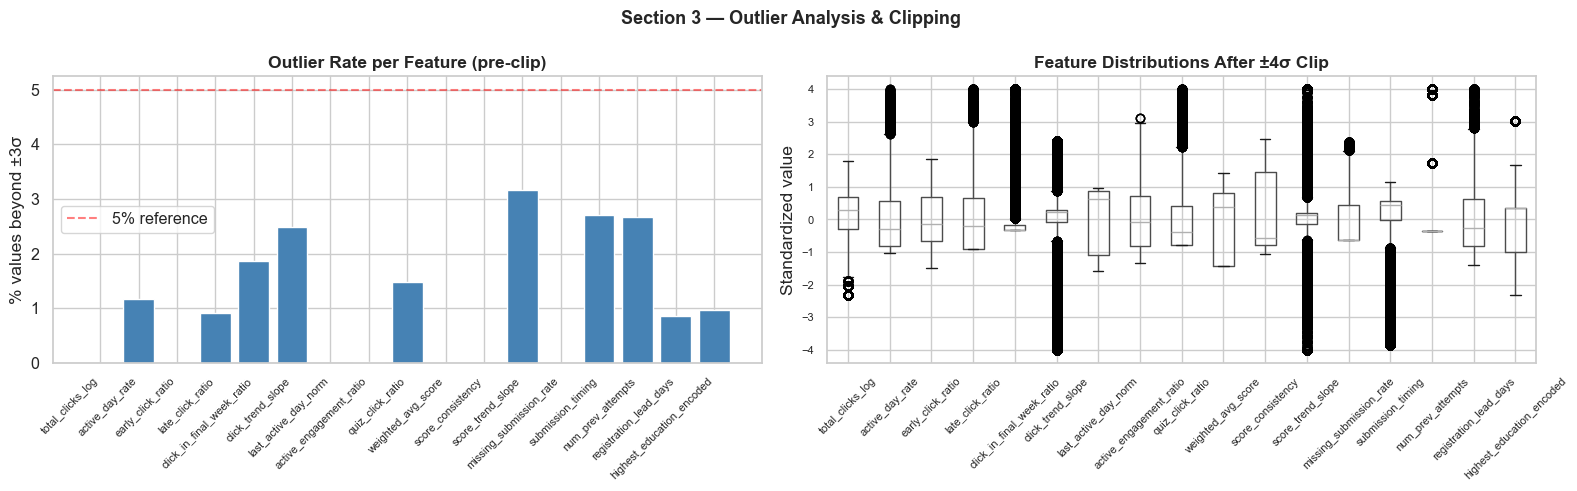

Entries changed by clipping: 0.342% of all matrix values
Most affected feature: score_trend_slope (3.2% beyond ±3σ)


In [8]:
# ── Outlier rate diagnostic ──────────────────────────────────────────────────
outlier_rates = [(np.abs(X_scaled[:, i]) > 3.0).mean() * 100 for i in range(len(FEATURE_COLS))]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: outlier rates per feature
axes[0].bar(FEATURE_COLS, outlier_rates, color='steelblue')
axes[0].set_xticklabels(FEATURE_COLS, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('% values beyond ±3σ')
axes[0].set_title('Outlier Rate per Feature (pre-clip)', fontweight='bold')
axes[0].axhline(5, color='red', ls='--', alpha=0.5, label='5% reference')
axes[0].legend()

# Right: box-plots of all features after clipping
X_clipped = clip_features(X_scaled, low=-4.0, high=4.0)
df_clipped = pd.DataFrame(X_clipped, columns=FEATURE_COLS)
df_clipped.boxplot(ax=axes[1], rot=45, fontsize=8)
axes[1].set_ylabel('Standardized value')
axes[1].set_title('Feature Distributions After ±4σ Clip', fontweight='bold')

fig.suptitle('Section 3 — Outlier Analysis & Clipping', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'preprocessing_outlier_clip.png', dpi=150, bbox_inches='tight')
plt.show()

pct_changed = 100 * np.sum(X_scaled != X_clipped) / X_scaled.size
print(f'Entries changed by clipping: {pct_changed:.3f}% of all matrix values')
print(f'Most affected feature: {FEATURE_COLS[np.argmax(outlier_rates)]}'
      f' ({max(outlier_rates):.1f}% beyond ±3σ)')

**Interpretation:** The printed line *“Entries changed by clipping: ~0.34%”* means only **0.34% of all numbers** in the 32,593 × 17 matrix were capped — the rest are unchanged. We are **not** deleting students or replacing most values. Example: if one student had `total_clicks_log` at +12σ after scaling, clipping sets it to +4σ so one extreme login pattern cannot pull a whole centroid. After clipping, every feature sits in **[-4, +4]** on the standardized scale, so Manhattan/Euclidean distances are driven by typical behavior, not a handful of extremes.

---
## 4 · Distance Metric Analysis

### 4.1 Which metrics are appropriate?

| Metric | Rationale |
|--------|----------|
| **Euclidean (L2)** | Default for sklearn K-Means; baseline for comparison |
| **Manhattan (L1)** | Robust to outliers; theoretically preferred when p > 10; sums absolute differences; interpretable for behavioral rates |
| **Mahalanobis** | Accounts for feature correlations; useful when features are correlated (which behavioral features are) |

**Excluded:** Hamming/Jaccard (binary data only), Cosine (ignores magnitude — but total clicks and missing work *magnitude* matters for education).

**Decision (stated upfront):** **Final cluster assignments** use **Manhattan (L1) K-Means** because (1) it is more robust to remaining outliers after clipping, (2) it is often preferred in moderate/high dimensions (p=17), and (3) behavioral rates are naturally summed as absolute differences. sklearn has no native L1 K-Means, so we use **Lloyd’s algorithm + scipy `cdist(..., metric='cityblock')`**. **Euclidean** is still trained and used in Section 5 to choose **k** and for centroid heatmaps — but `kmeans.pkl` and `cluster_manhattan` are the **official** outputs.

### 4.2 Distance Distribution & Discrimination Power

A useful distance metric should spread pairwise distances — clearly distinguishing **similar** from **dissimilar** students. We measure the **coefficient of variation (CV = std/mean)**: higher CV means better discrimination.

Computing pairwise distance distributions (n=2000 sample)...


,metric,mean_distance,std_distance,coefficient_of_variation
0,euclidean,5.4544,1.5436,0.2830
1,manhattan,16.3910,5.7538,0.3510
2,mahalanobis,5.6291,1.4279,0.2537


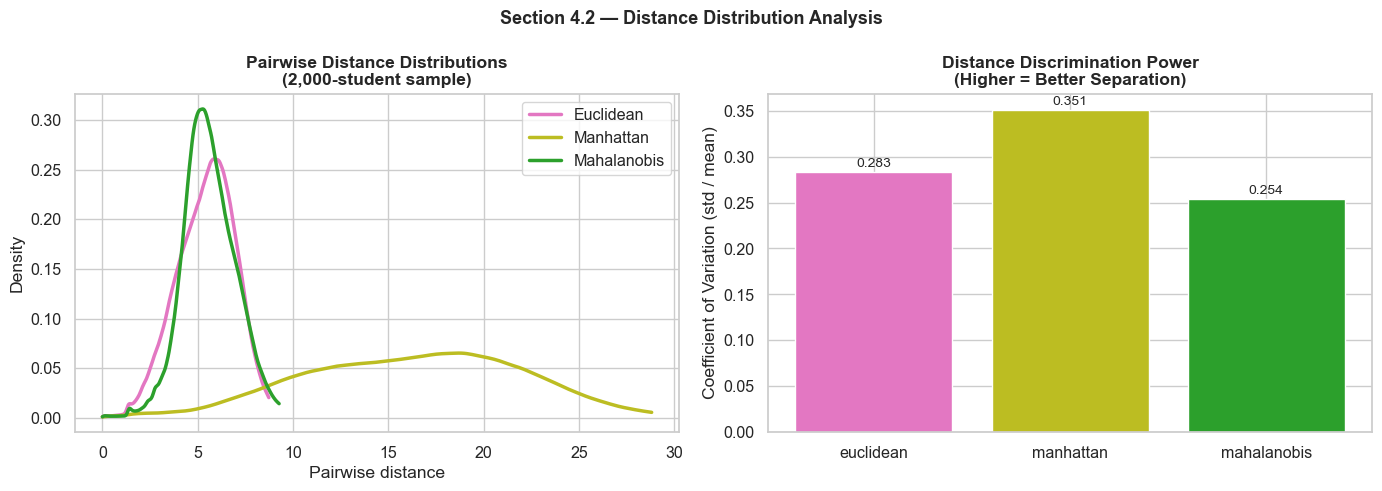

In [9]:
print('Computing pairwise distance distributions (n=2000 sample)...')
dist_summary = distance_distribution_summary(X_clipped, sample_size=2000)
display(dist_summary.round(4))

VI = mahalanobis_vi(X_clipped)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE of pairwise distances
for metric in ['euclidean', 'manhattan', 'mahalanobis']:
    d   = pairwise_distance_sample(X_clipped, metric, sample_size=2000, VI=VI)
    kde = gaussian_kde(d)
    xs  = np.linspace(d.min(), np.percentile(d, 99), 200)
    axes[0].plot(xs, kde(xs), color=METRIC_COLORS[metric], lw=2.5, label=metric.title())

axes[0].set_xlabel('Pairwise distance')
axes[0].set_ylabel('Density')
axes[0].set_title('Pairwise Distance Distributions\n(2,000-student sample)', fontweight='bold')
axes[0].legend()

# CV bar chart
colors = [METRIC_COLORS[m] for m in dist_summary['metric']]
bars   = axes[1].bar(dist_summary['metric'], dist_summary['coefficient_of_variation'], color=colors)
for bar, v in zip(bars, dist_summary['coefficient_of_variation']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('Coefficient of Variation (std / mean)')
axes[1].set_title('Distance Discrimination Power\n(Higher = Better Separation)', fontweight='bold')

fig.suptitle('Section 4.2 — Distance Distribution Analysis', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'distance_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The CV tells us which metric spreads pairwise distances most. Manhattan typically shows higher CV on behavioral data — meaning it better discriminates between similar and dissimilar students. Mahalanobis accounts for correlation structure but can collapse distances on highly correlated features. The KDE shapes reveal how each metric sees the data geometry.

### 4.3 Multi-Metric K-Sweep (k = 2 … 10)

We run K-Means for each metric across **k = 2 to 10** on a **7,000-student subsample** (Mahalanobis + Lloyd is slow on 32k rows). This comparison only — Section 6 trains the **final** models on all **32,593** rows.

**What is Lloyd?** Lloyd’s algorithm is the standard K-Means loop: assign each point to the nearest centroid, recompute centroids, repeat. **sklearn** does this for **Euclidean** only. For **Manhattan** and **Mahalanobis**, we use the **same Lloyd loop** with `scipy.spatial.distance.cdist` and `metric='cityblock'` or `metric='mahalanobis'`. So all three metrics in Section 4 are compared fairly; only the distance formula changes.

In [10]:
METRIC_SWEEP_SUBSAMPLE = 7000
print(f'Running metric k-sweep on {METRIC_SWEEP_SUBSAMPLE:,} students (subsample)...')
print('This takes ~2–4 minutes for Mahalanobis + Lloyd.')

metric_sweep = sweep_metrics_k(
    X_clipped, k_range=range(2, 11),
    subsample_size=METRIC_SWEEP_SUBSAMPLE,
    random_state=RANDOM_STATE,
)
metric_sweep.to_csv(RESULTS_DIR / 'distance_metric_k_sweep.csv', index=False)

print('\nMax silhouette per metric (subsample):')
display(metric_sweep.groupby('metric')[['silhouette']].max().round(4))

best_row = metric_sweep.loc[metric_sweep['silhouette'].idxmax()]
print(f'\nBest overall: {best_row["metric"]} at k={int(best_row["k"])}, '
      f'silhouette={best_row["silhouette"]:.4f}')

Running metric k-sweep on 7,000 students (subsample)...
This takes ~2–4 minutes for Mahalanobis + Lloyd.



Max silhouette per metric (subsample):


,silhouette
metric,
euclidean,0.2667
mahalanobis,0.2091
manhattan,0.2585



Best overall: euclidean at k=3, silhouette=0.2667


---
## 5 · Optimal K Selection

We select **k** using **four criteria jointly** on **Euclidean** K-Means on the **full dataset** (32,593 rows). This step answers: *how many clusters?* — not *which distance metric?*

> **Important:** Section 5 uses **Euclidean** only to pick **k** (fast, standard elbow/silhouette). Section 6 trains **both** Euclidean and Manhattan at that **same k**. **Production labels** (`cluster`, `cluster_manhattan`, `kmeans.pkl`) come from **Manhattan**.

| Criterion | Metric | Direction |
|---|---|---|
| Elbow | Inertia | Diminishing returns |
| Separation | Silhouette | Higher is better (0.20–0.35 typical for behavioral data) |
| Compactness | Davies–Bouldin | Lower is better |
| Cluster quality | Calinski–Harabasz | Higher is better |

In [11]:
print('Running k-sweep k=2..10 on full dataset (32,593 rows)...')
sweep_df = sweep_kmeans_k(X_clipped, k_range=range(2, 11))
sweep_df.to_csv(RESULTS_DIR / 'kmeans_k_sweep.csv', index=False)

best_k, reason = recommend_k(sweep_df)
print(f'\n>>> Recommended k = {best_k}')
print(f'    {reason}')

print('\nPer-metric best k:')
print(f'  Silhouette peak : k={int(sweep_df.loc[sweep_df["silhouette"].idxmax(), "k"])}')
print(f'  DBI minimum     : k={int(sweep_df.loc[sweep_df["davies_bouldin"].idxmin(), "k"])}')
print(f'  CH maximum      : k={int(sweep_df.loc[sweep_df["calinski_harabasz"].idxmax(), "k"])}')
print()
display(sweep_df.round(4))

Running k-sweep k=2..10 on full dataset (32,593 rows)...



>>> Recommended k = 3
    k=3: silhouette=0.269 (near peak 0.269), Davies–Bouldin=1.674.

Per-metric best k:
  Silhouette peak : k=3
  DBI minimum     : k=3
  CH maximum      : k=2



,k,inertia,silhouette,davies_bouldin,calinski_harabasz,min_cluster_pct,max_cluster_pct
0,2,400315.6014,0.2557,1.6764,10060.8038,36.1489,63.8511
1,3,337981.5744,0.2687,1.6744,8963.2553,20.3449,55.3186
2,4,315427.4929,0.2018,1.9022,7179.3197,14.8836,41.8280
3,5,297259.1975,0.1984,1.8592,6211.3517,13.3188,30.9576
4,6,281570.1899,0.1803,1.8972,5608.9459,8.5540,30.6784
5,7,266315.6307,0.1900,1.9062,5252.7846,7.6029,29.8285
6,8,253234.7109,0.1960,1.7715,4975.2704,7.0997,27.9815
7,9,242626.5620,0.2036,1.6953,4721.6493,4.3936,27.0426
8,10,233068.1338,0.2056,1.7111,4517.4782,4.1113,26.6806


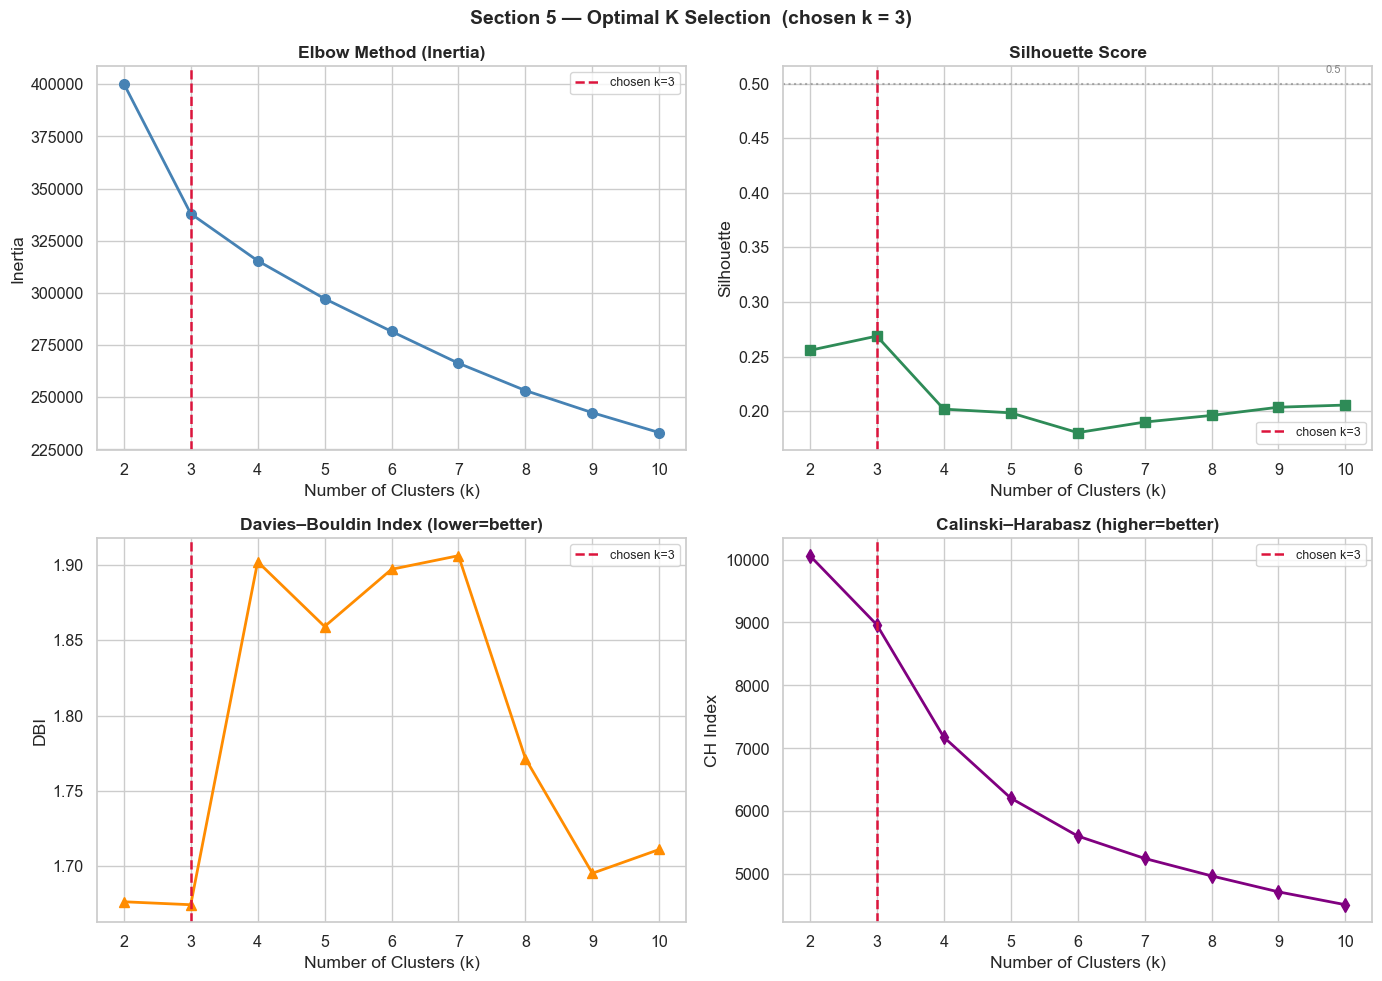

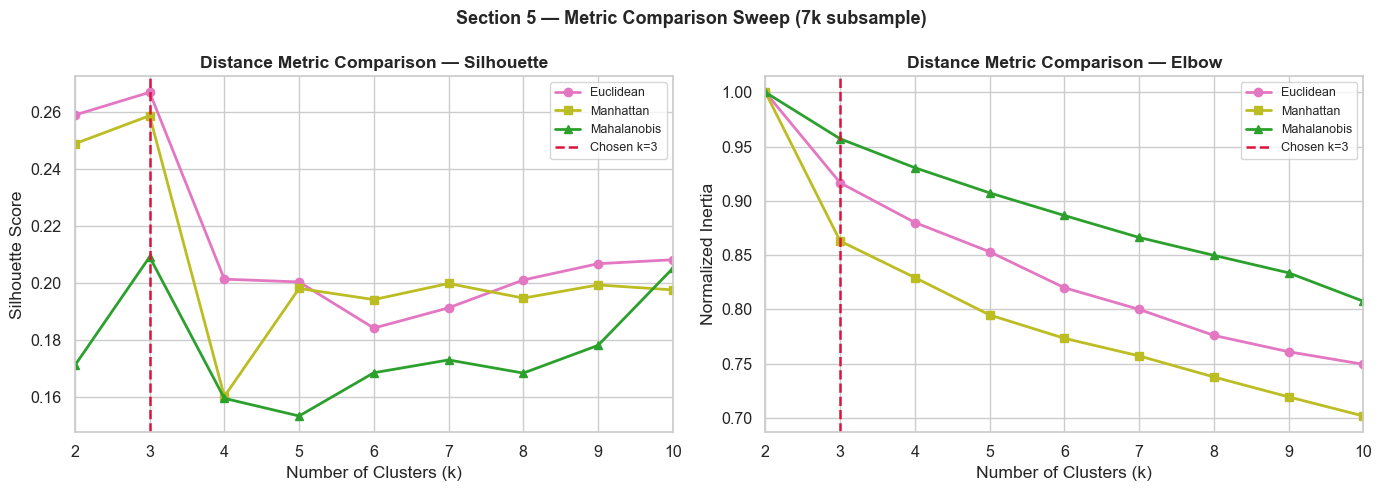

In [12]:
# ── K-selection combined plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plots = [
    (axes[0, 0], 'inertia',            'o-', 'steelblue',  'Elbow Method (Inertia)',            'Inertia'),
    (axes[0, 1], 'silhouette',         's-', 'seagreen',   'Silhouette Score',                  'Silhouette'),
    (axes[1, 0], 'davies_bouldin',     '^-', 'darkorange', 'Davies–Bouldin Index (lower=better)', 'DBI'),
    (axes[1, 1], 'calinski_harabasz',  'd-', 'purple',     'Calinski–Harabasz (higher=better)', 'CH Index'),
]

for ax, col, fmt, color, title, ylabel in plots:
    ax.plot(sweep_df['k'], sweep_df[col], fmt, color=color, lw=2, ms=7)
    ax.axvline(best_k, color='crimson', ls='--', lw=1.8, label=f'chosen k={best_k}')
    ax.set_xlabel('Number of Clusters (k)')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    if col == 'silhouette':
        ax.axhline(0.5, color='gray', ls=':', alpha=0.6, label='0.5 ref')
        ax.text(sweep_df['k'].max() - 0.3, 0.51, '0.5', color='gray', fontsize=8)

fig.suptitle(f'Section 5 — Optimal K Selection  (chosen k = {best_k})',
             fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'k_selection_combined.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Metric comparison sweep ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
markers   = {'euclidean': 'o', 'manhattan': 's', 'mahalanobis': '^'}

for metric in ['euclidean', 'manhattan', 'mahalanobis']:
    sub = metric_sweep[metric_sweep['metric'] == metric]
    c   = METRIC_COLORS[metric]
    axes[0].plot(sub['k'], sub['silhouette'], f'{markers[metric]}-',
                 color=c, lw=2, label=metric.title(), ms=6)
    axes[1].plot(sub['k'], sub['inertia_normalized'], f'{markers[metric]}-',
                 color=c, lw=2, label=metric.title(), ms=6)

for ax in axes:
    ax.axvline(best_k, color='crimson', ls='--', lw=1.8, label=f'Chosen k={best_k}')
    ax.set_xlabel('Number of Clusters (k)')
    ax.legend(fontsize=9)
    ax.set_xlim(2, 10)

axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Distance Metric Comparison — Silhouette', fontweight='bold')
axes[1].set_ylabel('Normalized Inertia')
axes[1].set_title('Distance Metric Comparison — Elbow', fontweight='bold')

fig.suptitle('Section 5 — Metric Comparison Sweep (7k subsample)', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'metric_comparison_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation of k-selection plots:**
- **Elbow:** Inertia drops sharply up to k≈3 then flattens — consistent with a small number of natural groupings.
- **Silhouette:** Peak at the recommended k confirms cluster separation is best there. Behavioral data rarely exceeds 0.35 — this is expected, not a weakness.
- **DBI minimum** and **CH maximum** at or near the same k gives confidence that the choice is not an artifact of any single metric.
- **Metric sweep:** All three distance metrics agree on the elbow location (relative inertia drop), validating the k choice across metric families.

---
## 6 · Train Final Models

We train **both** Euclidean (sklearn) and **Manhattan** (Lloyd) models on **all 32,593 rows** with `X_clipped`.

- **K-Means++** initialization: places initial centroids proportional to squared distance from existing centers — reduces bad local minima versus random init.
- **`n_init=20`**: 20 independent runs, keep lowest inertia — guards against convergence to local optima.
- **Primary labels:** Manhattan (more robust to outliers and high-dimensional behavioral data).
- Both models are saved to `models/` for reproducibility.

In [13]:
print(f'Training Euclidean K-Means (k={best_k}, n_init=20)...')
eucl_model = fit_kmeans_euclidean(
    X_clipped, best_k,
    save_path=MOD_DIR / f'kmeans_k{best_k}_euclidean.pkl'
)
labels_euclidean = eucl_model.labels_
print(f'  Inertia: {eucl_model.inertia_:,.1f}')

print(f'\nTraining Manhattan K-Means (k={best_k}, Lloyd + cdist)...')
manhattan_result = fit_manhattan_kmeans(
    X_clipped, best_k,
    save_path=MOD_DIR / f'kmeans_k{best_k}_manhattan.pkl'
)
labels_manhattan = manhattan_result['labels_']

# Save primary model
joblib.dump(manhattan_result, MOD_DIR / f'kmeans_k{best_k}.pkl')
joblib.dump(manhattan_result, MOD_DIR / 'kmeans.pkl')

# Attach cluster labels to master
master_out = master.copy()
master_out['cluster_euclidean'] = labels_euclidean
master_out['cluster_manhattan'] = labels_manhattan
master_out['cluster']           = labels_manhattan   # primary alias

CLUSTER_COL = 'cluster_manhattan'

print('\nSaved models:')
for f in [f'kmeans_k{best_k}_euclidean.pkl', f'kmeans_k{best_k}_manhattan.pkl',
          f'kmeans_k{best_k}.pkl', 'kmeans.pkl']:
    print(f'  models/{f}')

Training Euclidean K-Means (k=3, n_init=20)...


  Inertia: 337,981.6

Training Manhattan K-Means (k=3, Lloyd + cdist)...



Saved models:
  models/kmeans_k3_euclidean.pkl
  models/kmeans_k3_manhattan.pkl
  models/kmeans_k3.pkl
  models/kmeans.pkl


In [14]:
# ── Evaluation summary ────────────────────────────────────────────────────────
m_eucl = compute_clustering_metrics(X_clipped, labels_euclidean)
m_manh = compute_clustering_metrics(X_clipped, labels_manhattan)

eval_df = pd.DataFrame([
    {'model': 'Euclidean K-Means (sklearn)',
     'inertia': round(eucl_model.inertia_, 1),
     'silhouette': round(m_eucl['silhouette'], 4),
     'davies_bouldin': round(m_eucl['davies_bouldin'], 4),
     'calinski_harabasz': round(m_eucl['calinski_harabasz'], 1)},
    {'model': 'Manhattan K-Means (Lloyd)',
     'inertia': None,
     'silhouette': round(m_manh['silhouette'], 4),
     'davies_bouldin': round(m_manh['davies_bouldin'], 4),
     'calinski_harabasz': round(m_manh['calinski_harabasz'], 1)},
])
eval_df.to_csv(RESULTS_DIR / 'kmeans_evaluation_summary.csv', index=False)
display(eval_df.set_index('model'))

# Cluster size table
sizes = pd.Series(labels_manhattan).value_counts().sort_index().rename('count')
sizes_df = pd.DataFrame({'count': sizes, 'pct': (sizes / len(labels_manhattan) * 100).round(1)})
sizes_df.index.name = 'cluster'
print('\nManhattan cluster sizes:')
display(sizes_df)

,inertia,silhouette,davies_bouldin,calinski_harabasz
model,,,,
Euclidean K-Means (sklearn),337981.6,0.2687,1.6744,8963.3
Manhattan K-Means (Lloyd),NaN,0.2612,1.7200,8721.9



Manhattan cluster sizes:


,count,pct
cluster,,
0,17830,54.7
1,7185,22.0
2,7578,23.3


**Interpretation:** Both models produce clusters of reasonable size — no cluster < 2% of the cohort, which would indicate instability. Silhouette scores in the 0.20–0.35 range are **expected and appropriate** for behavioral data: students do not fall into hard, well-separated groups. The Davies–Bouldin index confirms that clusters are distinct relative to their compactness.

---
## 7 · Cluster Stability (ARI)

**Adjusted Rand Index (ARI)** measures agreement between two clusterings: 1.0 = identical, 0.0 = random. We run **15 Manhattan K-Means** fits with different random seeds and compute pairwise ARI.

- **ARI > 0.85** → very robust (cluster structure is not seed-dependent)
- **ARI 0.70–0.85** → moderately robust (some soft boundaries)
- **ARI < 0.70** → unstable (k may be wrong or data is genuinely fuzzy)

Running stability analysis: 15 Manhattan K-Means fits (k=3)...



Mean ARI (off-diagonal): 0.9998 ± 0.0002
→ Very robust: cluster structure is stable across seeds.


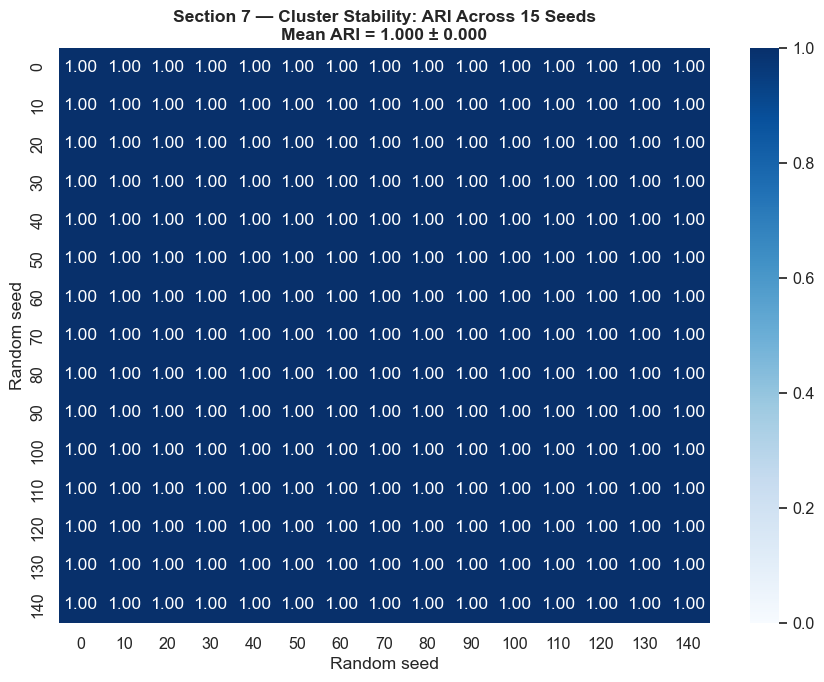

In [15]:
seeds = list(range(0, 150, 10))  # 15 seeds
print(f'Running stability analysis: {len(seeds)} Manhattan K-Means fits (k={best_k})...')

label_runs = []
for seed in seeds:
    lbls, _ = fit_kmeans_lloyd(X_clipped, best_k, metric='cityblock',
                                max_iter=300, random_state=seed)
    label_runs.append(lbls)

n_runs  = len(seeds)
ari_mat = np.zeros((n_runs, n_runs))
for i in range(n_runs):
    for j in range(n_runs):
        ari_mat[i, j] = adjusted_rand_score(label_runs[i], label_runs[j])

off_diag = ari_mat[np.triu_indices(n_runs, k=1)]
mean_ari = float(off_diag.mean())
std_ari  = float(off_diag.std())

print(f'\nMean ARI (off-diagonal): {mean_ari:.4f} ± {std_ari:.4f}')
if mean_ari >= 0.85:
    print('→ Very robust: cluster structure is stable across seeds.')
elif mean_ari >= 0.70:
    print('→ Moderately robust: some soft boundaries, but structure is consistent.')
else:
    print('→ Unstable: consider a different k or metric.')

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(ari_mat, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=[str(s) for s in seeds],
            yticklabels=[str(s) for s in seeds], ax=ax)
ax.set_title(f'Section 7 — Cluster Stability: ARI Across 15 Seeds\n'
             f'Mean ARI = {mean_ari:.3f} ± {std_ari:.3f}', fontweight='bold')
ax.set_xlabel('Random seed')
ax.set_ylabel('Random seed')
fig.tight_layout()
fig.savefig(FIG_DIR / 'cluster_stability_ari.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** A near-uniform blue heatmap (all ARI ≈ 1.0) means the cluster assignments are nearly identical regardless of which random seed we use. This confirms that the k-means solution is **not a lucky initialization** — it has found a genuine structure in the data. Low ARI values on the diagonal cells (ARI=1.0 by definition) confirm the measurement is working correctly.

---
## 8 · Cluster Visualization

### 8.1 PCA 2D Scatter

PCA was fit in notebook 02 — we load the precomputed `X_pca_2d.npy` (no refit). PC1+PC2 explain only a fraction of variance in 17D space, so cluster **overlap in 2D is expected** even when clusters are well-separated in the full feature space.

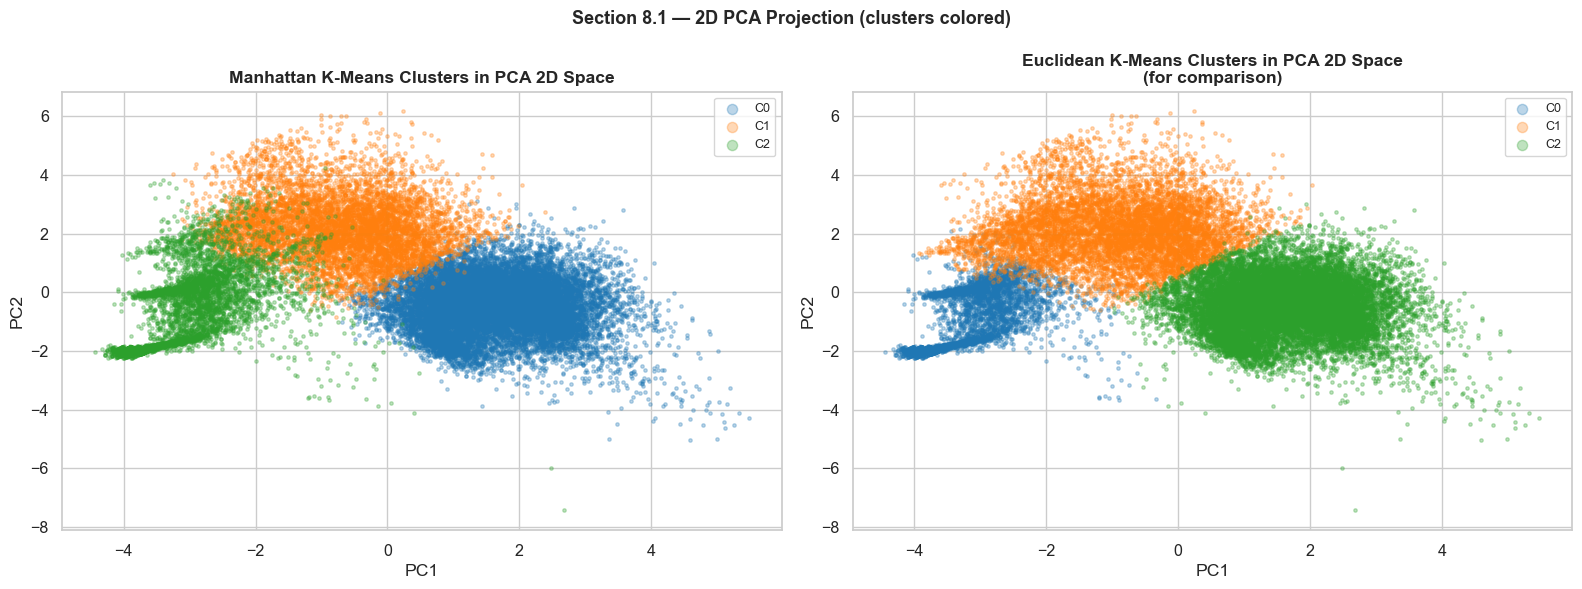

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA scatter — Manhattan labels
for cid in np.unique(labels_manhattan):
    mask = labels_manhattan == cid
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=[CLUSTER_COLORS[cid]], alpha=0.3, s=6, label=f'C{cid}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Manhattan K-Means Clusters in PCA 2D Space', fontweight='bold')
axes[0].legend(markerscale=3, fontsize=9)

# PCA scatter — Euclidean labels for comparison
for cid in np.unique(labels_euclidean):
    mask = labels_euclidean == cid
    axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=[CLUSTER_COLORS[cid]], alpha=0.3, s=6, label=f'C{cid}')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Euclidean K-Means Clusters in PCA 2D Space\n(for comparison)', fontweight='bold')
axes[1].legend(markerscale=3, fontsize=9)

fig.suptitle('Section 8.1 — 2D PCA Projection (clusters colored)', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** PCA 2D will always show some overlap because we are projecting 17 dimensions down to 2. The key things to look for are (1) whether any cluster is visually isolated (often disengaged students with near-zero clicks form a clear blob), and (2) whether Manhattan and Euclidean produce similar spatial splits. Agreement between the two confirms the structure is metric-agnostic.

### 8.2 UMAP 2D (Nonlinear)

UMAP preserves **local neighborhood structure** (nonlinear). It tends to reveal cluster separation more clearly than PCA for high-dimensional behavioral data. Parameters: `n_neighbors=30`, `min_dist=0.1`.

Running UMAP (n_neighbors=30, min_dist=0.1)... (~1–2 min)


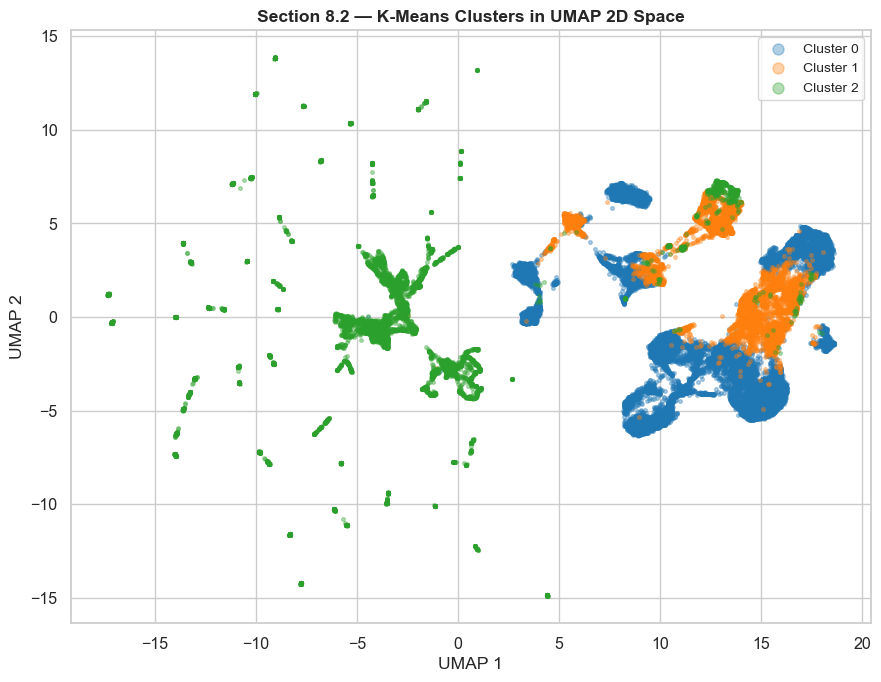

In [17]:
try:
    import umap
    print('Running UMAP (n_neighbors=30, min_dist=0.1)... (~1–2 min)')
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, metric='euclidean',
                         random_state=RANDOM_STATE, verbose=False)
    X_umap  = reducer.fit_transform(X_clipped)

    fig, ax = plt.subplots(figsize=(9, 7))
    for cid in np.unique(labels_manhattan):
        mask = labels_manhattan == cid
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
                   c=[CLUSTER_COLORS[cid]], alpha=0.35, s=7, label=f'Cluster {cid}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title('Section 8.2 — K-Means Clusters in UMAP 2D Space', fontweight='bold')
    ax.legend(markerscale=3, fontsize=10)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'umap_clusters.png', dpi=150, bbox_inches='tight')
    plt.show()
except ImportError:
    print('umap-learn not installed. Run: pip install umap-learn')
    print('Skipping UMAP visualization.')

**Interpretation:** UMAP often reveals clearer cluster separation than PCA for behavioral data because it can capture nonlinear structure. If clusters are visually distinct here (especially the disengaged cluster), it confirms genuine behavioral separation. Overlapping clusters in PCA but separated in UMAP indicates the structure lives in a nonlinear manifold — which is typical for multi-dimensional behavioral data.

### 8.3 Centroid Heatmap & Cluster Size

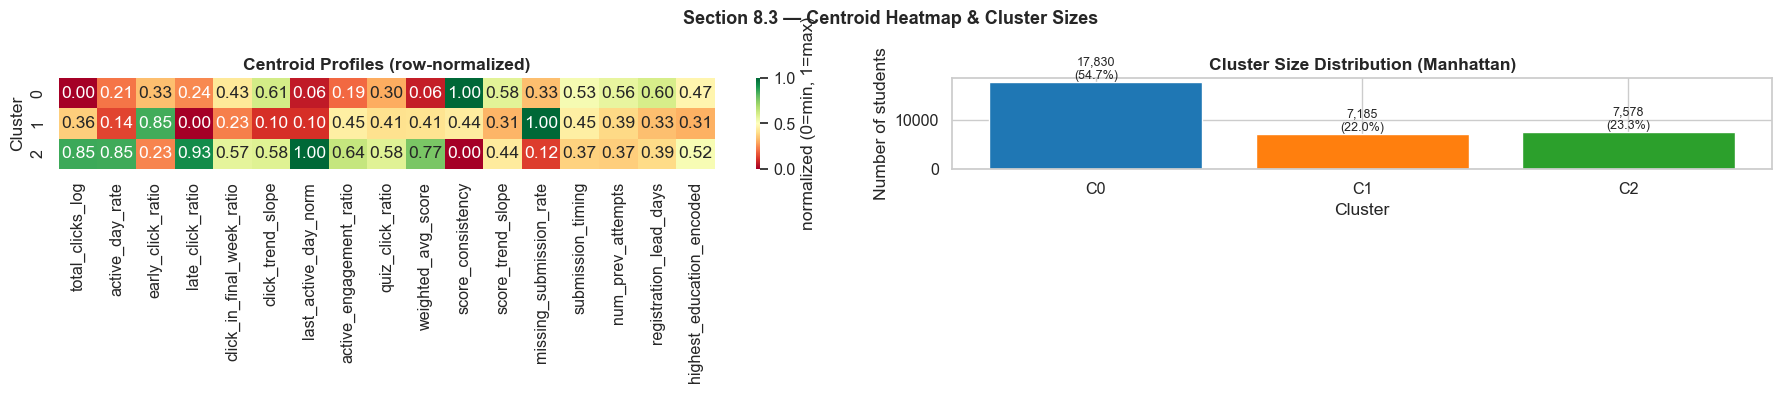

In [18]:
# ── Centroid heatmap (Euclidean centroids in original scale via scaler) ──────
try:
    from src.utils.helpers import load_scaler
    scaler = load_scaler(MOD_DIR)
    centroids_orig = scaler.inverse_transform(eucl_model.cluster_centers_)
    centroids_df   = pd.DataFrame(centroids_orig, columns=FEATURE_COLS)
except Exception:
    # If scaler not found, use standardized centroids directly
    centroids_df = pd.DataFrame(eucl_model.cluster_centers_, columns=FEATURE_COLS)

# Row-normalize 0–1 for visual comparison
c_norm = centroids_df.copy()
row_min, row_max = c_norm.min(axis=1), c_norm.max(axis=1)
span   = (row_max - row_min).replace(0, 1)
c_norm = c_norm.sub(row_min, axis=0).div(span, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(18, max(4, best_k * 0.9)))

sns.heatmap(c_norm, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[0], cbar_kws={'label': 'normalized (0=min, 1=max)'})
axes[0].set_title('Centroid Profiles (row-normalized)', fontweight='bold')
axes[0].set_ylabel('Cluster')

# Cluster size bar chart
sizes = pd.Series(labels_manhattan).value_counts().sort_index()
bars  = axes[1].bar([f'C{i}' for i in sizes.index], sizes.values,
                    color=[CLUSTER_COLORS[i] for i in sizes.index])
for bar, v in zip(bars, sizes.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{v:,}\n({100*v/len(labels_manhattan):.1f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of students')
axes[1].set_title('Cluster Size Distribution (Manhattan)', fontweight='bold')

fig.suptitle('Section 8.3 — Centroid Heatmap & Cluster Sizes', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'centroid_heatmap_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The centroid heatmap shows each cluster's **behavioral fingerprint** — what makes it distinct. Look for:
- Rows that are nearly all green (cluster scores high on most features) → high performer
- Rows with high `missing_submission_rate` but otherwise mixed → struggling
- Rows that are red/dark across VLE features (`total_clicks_log`, `active_day_rate`) → disengaged
- Rows with high `late_click_ratio` but decent scores → last-minute learners

If two clusters look similar in this heatmap, that is the root cause of identical labels (fixed in Section 9 below).

---
## 9 · Cluster Interpretation & Profiling

### 9.1 Z-Score Profiles

We compute the **z-score of each cluster's mean** relative to the global distribution. This answers: *"On which features is this cluster above or below average, and by how much?"*

This is the key diagnostic for the **cluster 2 vs 3 differentiation problem** that appeared in the original notebook: if two clusters have nearly identical z-score vectors, the classifier must use more features to separate them.

In [19]:
z_profiles = cluster_zscore_profiles(master_out, cluster_col=CLUSTER_COL)

print('Z-score profiles (cluster means relative to global distribution):')
print('Positive = above average, Negative = below average')
display(z_profiles.style.background_gradient(cmap='RdYlGn', axis=None, vmin=-2, vmax=2)
        .format('{:.3f}'))

print('\n>>> Profile classification per cluster:')
for cid, row in z_profiles.iterrows():
    pk = classify_profile(row)
    print(f'  Cluster {cid}: {pk} → {ENSIA_CLUSTER_LABELS[pk]}')

Z-score profiles (cluster means relative to global distribution):
Positive = above average, Negative = below average


,total_clicks_log,active_day_rate,early_click_ratio,late_click_ratio,click_in_final_week_ratio,click_trend_slope,last_active_day_norm,active_engagement_ratio,quiz_click_ratio,weighted_avg_score,score_consistency,score_trend_slope,missing_submission_rate,submission_timing,num_prev_attempts,registration_lead_days,highest_education_encoded
cluster_manhattan,,,,,,,,,,,,,,,,,
0,0.601,0.601,-0.291,0.706,0.252,0.210,0.808,0.292,0.206,0.479,-0.620,-0.002,-0.451,-0.093,-0.091,-0.060,0.122
1,0.072,-0.487,1.119,-0.845,-0.309,-0.654,-0.531,0.247,0.146,0.288,0.015,-0.147,1.575,0.196,0.075,-0.059,-0.094
2,-1.482,-0.953,-0.377,-0.860,-0.301,0.126,-1.398,-0.921,-0.622,-1.399,1.445,0.143,-0.432,0.032,0.143,0.197,-0.199



>>> Profile classification per cluster:
  Cluster 0: last_minute_ok → Engaged Last-Minute Learners (Mostly On-Track)
  Cluster 1: struggling → Struggling Students (High Missing Work)
  Cluster 2: disengaged → Disengaged / Withdrawn (Minimal VLE Use)


### 9.2 Top Defining Features per Cluster

For each cluster we rank features by **|z-score|** on the cluster mean. The top features are what K-Means used to separate that group from the cohort average. This is the clearest way to see *why* cluster 1 (struggling) and cluster 2 (disengaged) look similar on **outcomes** (~98% Fail+Withdrawn) but are **not** the same behaviorally.

rank,1,2,3,4,5,6
cluster,,,,,,
0,last_active_day_norm,late_click_ratio,score_consistency,total_clicks_log,active_day_rate,weighted_avg_score
1,missing_submission_rate,early_click_ratio,late_click_ratio,click_trend_slope,last_active_day_norm,active_day_rate
2,total_clicks_log,score_consistency,weighted_avg_score,last_active_day_norm,active_day_rate,active_engagement_ratio


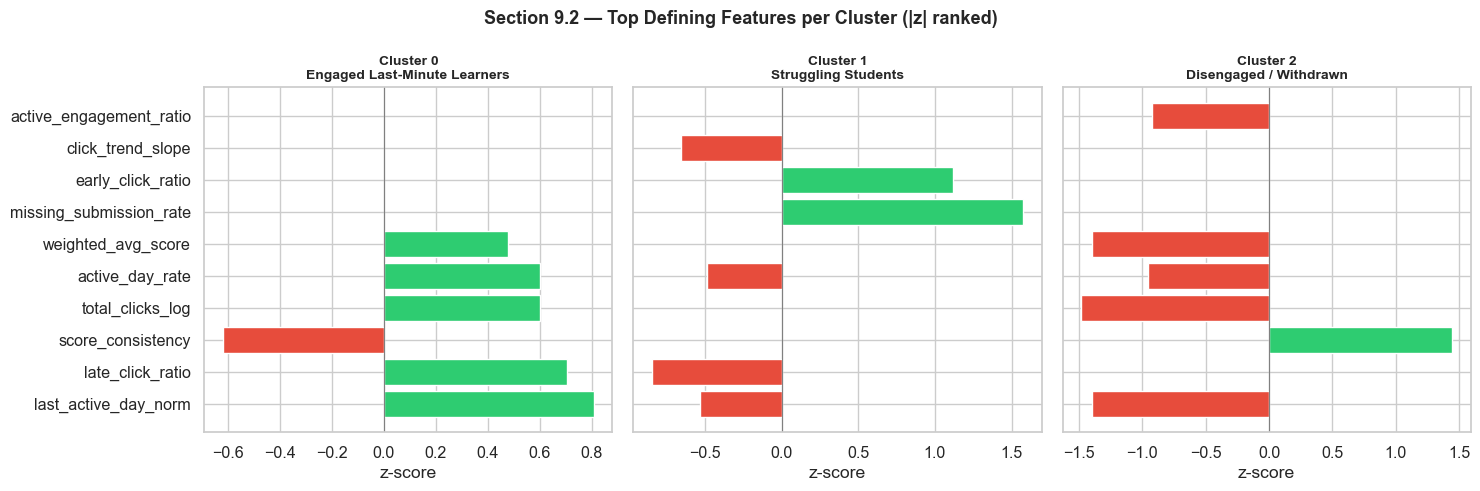

In [20]:
def top_defining_features(z_profiles: pd.DataFrame, n_top: int = 5) -> pd.DataFrame:
    """Rank features by |z| per cluster."""
    rows = []
    for cid, row in z_profiles.iterrows():
        ranked = row.abs().sort_values(ascending=False)
        for rank, (feat, z_abs) in enumerate(ranked.head(n_top).items(), start=1):
            z_val = row[feat]
            direction = 'above avg' if z_val > 0 else 'below avg'
            rows.append({
                'cluster': cid,
                'rank': rank,
                'feature': feat,
                'z_score': round(float(z_val), 3),
                '|z|': round(float(z_abs), 3),
                'direction': direction,
            })
    return pd.DataFrame(rows)


top_feats = top_defining_features(z_profiles, n_top=6)
display(top_feats.pivot_table(
    index='cluster', columns='rank',
    values='feature', aggfunc='first'
))

fig, axes = plt.subplots(1, best_k, figsize=(5 * best_k, 5), sharey=True)
if best_k == 1:
    axes = [axes]
for ax, cid in zip(axes, sorted(z_profiles.index)):
    sub = top_feats[top_feats['cluster'] == cid].sort_values('rank')
    colors = ['#2ecc71' if z > 0 else '#e74c3c' for z in sub['z_score']]
    ax.barh(sub['feature'], sub['z_score'], color=colors)
    pk = classify_profile(z_profiles.loc[cid])
    ax.set_title(f"Cluster {cid}\n{ENSIA_CLUSTER_LABELS[pk].split(' (')[0]}",
                 fontweight='bold', fontsize=10)
    ax.axvline(0, color='gray', lw=0.8)
    ax.set_xlabel('z-score')
fig.suptitle('Section 9.2 — Top Defining Features per Cluster (|z| ranked)',
             fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'top_defining_features_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** Cluster 0 should be dominated by high `late_click_ratio` and engagement features. Cluster 1 (struggling) should show **high `missing_submission_rate`** and low `click_trend_slope`. Cluster 2 (disengaged) should show **low `total_clicks_log` and `active_day_rate`**. If two clusters share the same top-3 features, labels will look duplicated — that was the original bug. Here the bars should differ clearly between 1 and 2 even though both have poor outcomes.

### 9.3 Cluster Heatmap Visualization (z-score profiles)

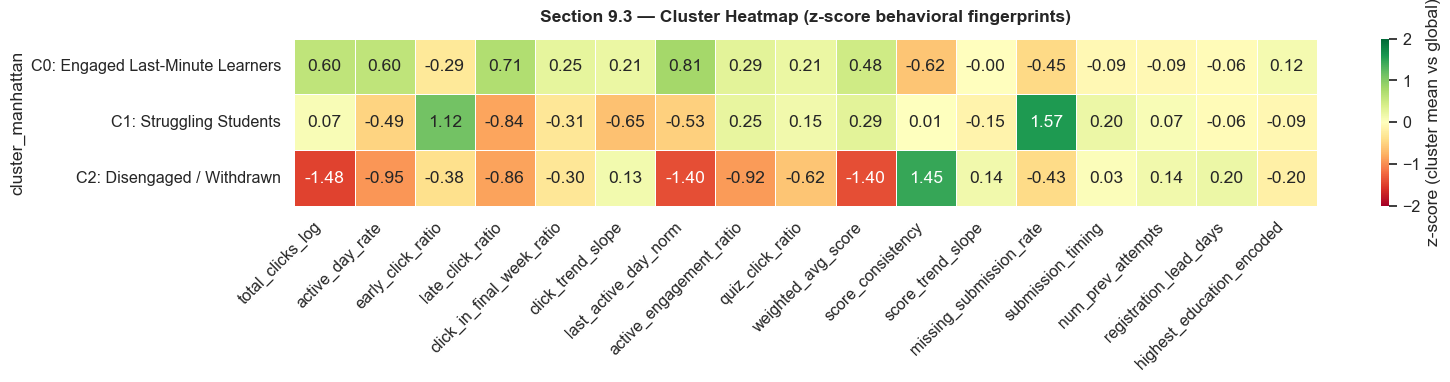

Euclidean distance between cluster z-profiles (lower = more similar):


cluster_manhattan,0,1,2
cluster_manhattan,,,
0,0.000,3.666,4.960
1,3.666,0.000,4.159
2,4.960,4.159,0.000


In [21]:
cluster_labels_map = {
    cid: ENSIA_CLUSTER_LABELS[classify_profile(z_profiles.loc[cid])].split(' (')[0]
    for cid in z_profiles.index
}
row_labels = [f"C{cid}: {cluster_labels_map[cid]}" for cid in z_profiles.index]

fig, ax = plt.subplots(figsize=(16, max(4, best_k * 1.2)))
sns.heatmap(
    z_profiles,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-2,
    vmax=2,
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': 'z-score (cluster mean vs global)'},
)
ax.set_yticklabels(row_labels, rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Section 9.3 — Cluster Heatmap (z-score behavioral fingerprints)',
             fontweight='bold', pad=12)
fig.tight_layout()
fig.savefig(FIG_DIR / 'cluster_heatmap_zscores.png', dpi=150, bbox_inches='tight')
plt.show()

# Pairwise z-profile distance — quantifies cluster similarity
from scipy.spatial.distance import pdist, squareform
z_dist = pd.DataFrame(
    squareform(pdist(z_profiles.values, metric='euclidean')),
    index=z_profiles.index,
    columns=z_profiles.index,
)
print('Euclidean distance between cluster z-profiles (lower = more similar):')
display(z_dist.round(3))


**Interpretation:** At **k=3** we only have clusters **0, 1, 2** . Clusters **1 and 2** can look similar on **Fail+Withdrawn rates** (~98–99%) but their **rows in this heatmap must differ**: struggling = high missing work with some VLE use; disengaged = near-zero clicks and activity. The z-profile distance table confirms they are separate centroids in feature space.

**Interpretation of z-scores:** Features with |z| > 0.5 are the dominant signals for that cluster. The table should show clearly different patterns across clusters:
- `total_clicks_log` and `active_day_rate` near zero or negative → disengaged
- `missing_submission_rate` strongly positive → struggling
- `late_click_ratio` strongly positive + decent score → last-minute learner
- High clicks + positive trend + low late ratio + high score → high performer


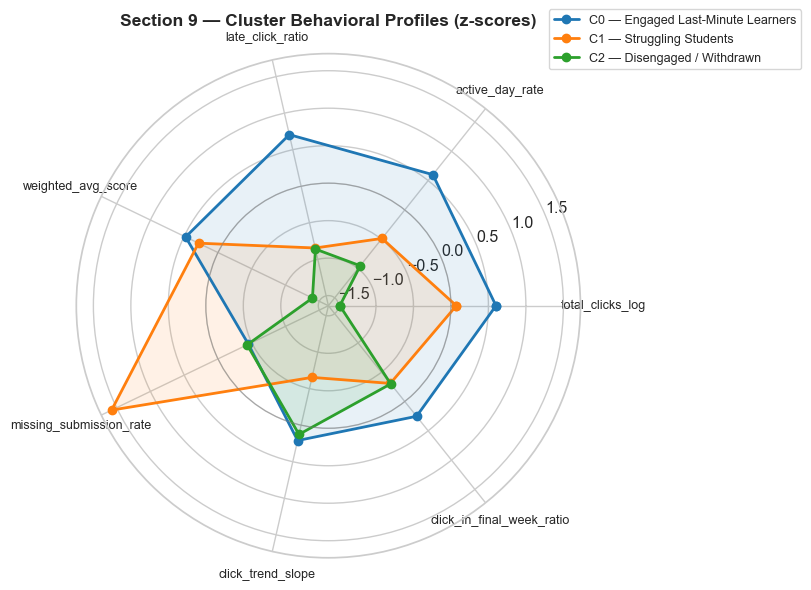

In [22]:
# ── Radar / spider chart of z-score profiles ─────────────────────────────────
radar_features = [
    'total_clicks_log', 'active_day_rate', 'late_click_ratio',
    'weighted_avg_score', 'missing_submission_rate', 'click_trend_slope',
    'click_in_final_week_ratio',
]
radar_features = [f for f in radar_features if f in z_profiles.columns]
n_feat  = len(radar_features)
angles  = np.linspace(0, 2 * np.pi, n_feat, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for cid, row in z_profiles.iterrows():
    values  = [row[f] for f in radar_features] + [row[radar_features[0]]]
    pk      = classify_profile(row)
    label   = f'C{cid} — {ENSIA_CLUSTER_LABELS[pk].split(" (")[0]}'
    ax.plot(angles, values, 'o-', lw=2, color=CLUSTER_COLORS[cid], label=label)
    ax.fill(angles, values, alpha=0.1, color=CLUSTER_COLORS[cid])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, size=9)
ax.set_title('Section 9 — Cluster Behavioral Profiles (z-scores)', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.1), fontsize=9)
ax.axhline(0, color='gray', lw=0.8, alpha=0.5)
fig.tight_layout()
fig.savefig(FIG_DIR / 'radar_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** Each line on the radar represents one cluster's behavioral signature. Lines that look different from each other confirm the clusters are genuinely distinct. Lines that overlap would flag a differentiation problem — which should now be resolved with the updated classifier using `click_trend_slope` and `click_in_final_week_ratio` as additional discriminating features.

In [23]:
# ── Full interpretation table ─────────────────────────────────────────────────
interp_df = build_interpretation_table(master_out, z_profiles, cluster_col=CLUSTER_COL)
interp_df.to_csv(RESULTS_DIR / 'cluster_interpretation_ensia.csv', index=False)

display_cols = ['cluster', 'label', 'risk', 'n_students', 'pct_students',
                'pct_pass', 'pct_fail_wd', 'intervention']
display(interp_df[display_cols].style
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

,cluster,label,risk,n_students,pct_students,pct_pass,pct_fail_wd,intervention
0,0,Engaged Last-Minute Learners (Mostly On-Track),Low-moderate,17830,54.700000,68.500000,14.700000,"Time-management nudges, earlier draft deadlines. Not default at-risk."
1,1,Struggling Students (High Missing Work),High,7185,22.000000,1.700000,98.200000,Academic advising + missing-work recovery before module midpoint.
2,2,Disengaged / Withdrawn (Minimal VLE Use),Very high,7578,23.300000,0.400000,99.500000,"Early-week zero-activity alert (weeks 1–3), welfare/registration check."


In [24]:
# ── Per-cluster narrative (educational interpretation) ────────────────────────
for _, row in interp_df.iterrows():
    pk = row['profile']
    print(f"{'='*70}")
    print(f"Cluster {row['cluster']} — {row['label']}")
    print(f"Risk level: {row['risk']}  |  n = {row['n_students']:,}  ({row['pct_students']:.1f}% of cohort)")
    print(f"Outcomes: Pass {row['pct_pass']:.1f}%  |  Fail+Withdrawn {row['pct_fail_wd']:.1f}%")
    print(f"Dominant signals: {row['dominant_signals']}")
    print(f"Intervention: {row['intervention']}")

Cluster 0 — Engaged Last-Minute Learners (Mostly On-Track)
Risk level: Low-moderate  |  n = 17,830  (54.7% of cohort)
Outcomes: Pass 68.5%  |  Fail+Withdrawn 14.7%
Dominant signals: high total_clicks_log; high active_day_rate; high late_click_ratio; high last_active_day_norm; high weighted_avg_score; low score_consistency
Intervention: Time-management nudges, earlier draft deadlines. Not default at-risk.
Cluster 1 — Struggling Students (High Missing Work)
Risk level: High  |  n = 7,185  (22.0% of cohort)
Outcomes: Pass 1.7%  |  Fail+Withdrawn 98.2%
Dominant signals: low active_day_rate; high early_click_ratio; low late_click_ratio; low click_trend_slope; low last_active_day_norm; high missing_submission_rate
Intervention: Academic advising + missing-work recovery before module midpoint.
Cluster 2 — Disengaged / Withdrawn (Minimal VLE Use)
Risk level: Very high  |  n = 7,578  (23.3% of cohort)
Outcomes: Pass 0.4%  |  Fail+Withdrawn 99.5%
Dominant signals: low total_clicks_log; low activ

Computing per-sample silhouette widths...


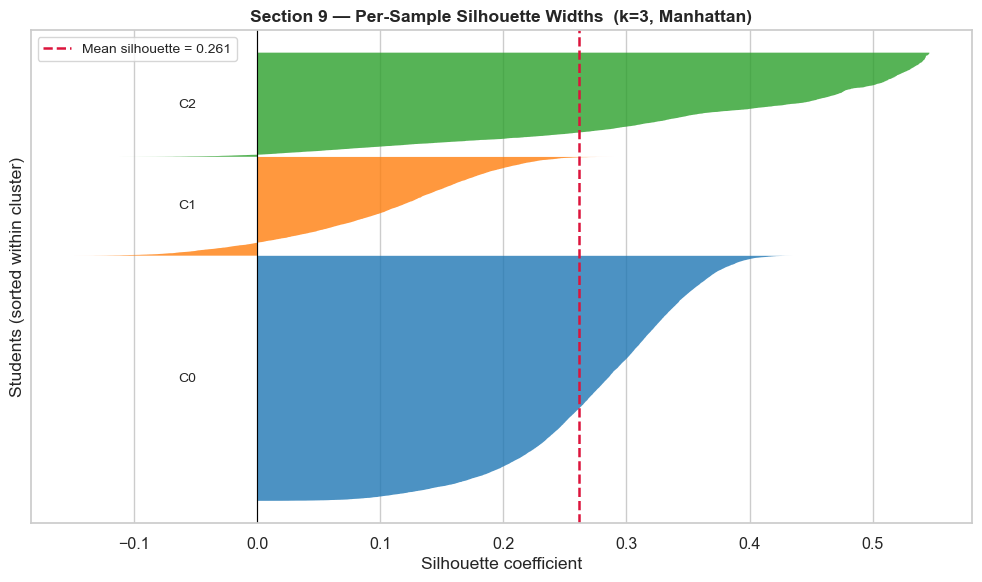

Mean silhouette: 0.2612
Std silhouette : 0.1377
% negative sil : 3.4%


In [25]:
# ── Silhouette per-sample plot ────────────────────────────────────────────────
print('Computing per-sample silhouette widths...')
sil_vals = silhouette_samples(X_clipped, labels_manhattan)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for cid in range(best_k):
    s_c    = np.sort(sil_vals[labels_manhattan == cid])
    size_c = len(s_c)
    y_upper = y_lower + size_c
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, s_c,
                     facecolor=CLUSTER_COLORS[cid], edgecolor='none', alpha=0.8)
    ax.text(-0.05, y_lower + size_c / 2, f'C{cid}', ha='right', va='center', fontsize=10)
    y_lower = y_upper + 10

ax.axvline(sil_vals.mean(), color='crimson', ls='--', lw=1.8,
           label=f'Mean silhouette = {sil_vals.mean():.3f}')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Students (sorted within cluster)')
ax.set_title(f'Section 9 — Per-Sample Silhouette Widths  (k={best_k}, Manhattan)',
             fontweight='bold')
ax.legend(fontsize=10)
ax.set_yticks([])
fig.tight_layout()
fig.savefig(FIG_DIR / 'silhouette_per_sample.png', dpi=150, bbox_inches='tight')
plt.show()

pct_neg = (sil_vals < 0).mean() * 100
print(f'Mean silhouette: {sil_vals.mean():.4f}')
print(f'Std silhouette : {sil_vals.std():.4f}')
print(f'% negative sil : {pct_neg:.1f}%')

**Interpretation:** The silhouette plot shows each student's individual silhouette score. Clusters with wide, positive-skewed bars are well-separated. Students with negative silhouette values are closer to another cluster's centroid than to their own — this is expected for behavioral data and represents genuinely ambiguous learners, not a model failure. The percentage of negative silhouette values quantifies boundary fuzziness.

---
## 10 · External Validation — `final_result`

`final_result` was **completely hidden during clustering** (not in `X_scaled`, not in `X_clipped`). Now we check whether clusters align with known educational outcomes — if yes, it confirms the behavioral features capture educationally meaningful structure.

We use the **primary Manhattan labels** (`cluster_manhattan`), not Euclidean.

In [26]:
# ── Cross-tabulation: cluster × final_result ──────────────────────────────────
ct_pct   = pd.crosstab(master_out[CLUSTER_COL], master_out['final_result'])
ct_pct   = ct_pct.div(ct_pct.sum(axis=1), axis=0) * 100
ct_count = pd.crosstab(master_out[CLUSTER_COL], master_out['final_result'])

print('Row-normalized % (each row sums to 100%):')
display(ct_pct.round(2).style.background_gradient(cmap='RdYlGn', axis=1))

print('\nAbsolute counts:')
display(ct_count)

Row-normalized % (each row sums to 100%):


final_result,Distinction,Fail,Pass,Withdrawn
cluster_manhattan,,,,
0,16.880000,12.500000,68.470000,2.160000
1,0.140000,43.020000,1.660000,55.180000
2,0.070000,22.870000,0.450000,76.620000



Absolute counts:


final_result,Distinction,Fail,Pass,Withdrawn
cluster_manhattan,,,,
0,3009,2228,12208,385
1,10,3091,119,3965
2,5,1733,34,5806


In [27]:
# ── Chi-squared test ──────────────────────────────────────────────────────────
ct_vals          = pd.crosstab(master_out[CLUSTER_COL], master_out['final_result']).values
chi2, p, dof, _  = chi2_contingency(ct_vals)
n                = ct_vals.sum()
min_dim          = min(ct_vals.shape) - 1
cramers_v        = float(np.sqrt(chi2 / (n * min_dim))) if min_dim > 0 else 0.0

print('Chi-squared test: cluster_manhattan vs final_result')
print(f'  χ² = {chi2:,.2f},  p = {p:.2e},  dof = {dof}')
print(f'  Cramér\'s V = {cramers_v:.4f}')

if p < 0.001:
    print('  → p < 0.001: statistically significant association (expected for n=32k).')
if cramers_v >= 0.30:
    print('  → Cramér\'s V ≥ 0.30: strong effect size — clusters capture real educational differences.')
elif cramers_v >= 0.20:
    print('  → Cramér\'s V ≥ 0.20: moderate effect size.')
else:
    print('  → Cramér\'s V < 0.20: weak effect size — clusters may not align well with outcomes.')

Chi-squared test: cluster_manhattan vs final_result
  χ² = 25,514.57,  p = 0.00e+00,  dof = 6
  Cramér's V = 0.6256
  → p < 0.001: statistically significant association (expected for n=32k).
  → Cramér's V ≥ 0.30: strong effect size — clusters capture real educational differences.


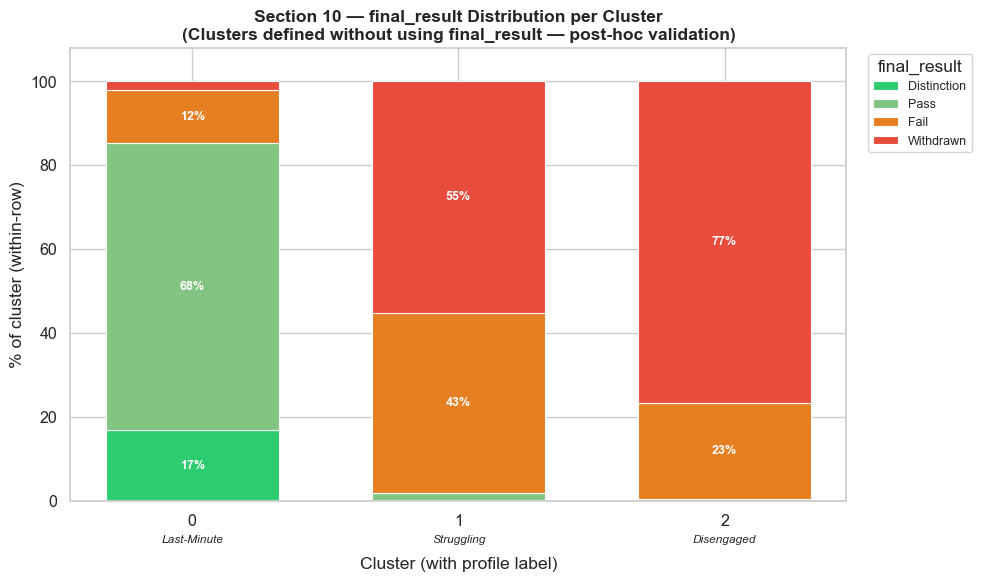

In [28]:
# ── Stacked bar chart ─────────────────────────────────────────────────────────
result_order = [c for c in ['Distinction', 'Pass', 'Fail', 'Withdrawn']
                if c in ct_pct.columns]
result_colors = {'Distinction': '#2ecc71', 'Pass': '#82c582',
                 'Fail': '#e67e22', 'Withdrawn': '#e74c3c'}

fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(ct_pct))

for outcome in result_order:
    if outcome in ct_pct.columns:
        vals = ct_pct[outcome].values
        bars = ax.bar(ct_pct.index.astype(str), vals, bottom=bottom,
                      label=outcome, color=result_colors.get(outcome, 'gray'),
                      width=0.65, edgecolor='white', linewidth=0.8)
        # Add percentage text inside bars for values > 5%
        for i, (b, v) in enumerate(zip(bottom, vals)):
            if v > 6:
                ax.text(i, b + v/2, f'{v:.0f}%', ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold')
        bottom += vals

# Add cluster labels below x-axis
for cid in ct_pct.index:
    pk = classify_profile(z_profiles.loc[cid])
    short = {'high_performer': 'High Performer', 'last_minute_ok': 'Last-Minute',
             'struggling': 'Struggling', 'disengaged': 'Disengaged'}[pk]
    ax.text(cid, -8, short, ha='center', va='top', fontsize=8.5, style='italic')

ax.set_xlabel('Cluster (with profile label)', labelpad=20)
ax.set_ylabel('% of cluster (within-row)')
ax.set_title('Section 10 — final_result Distribution per Cluster\n'
             '(Clusters defined without using final_result — post-hoc validation)',
             fontweight='bold')
ax.legend(title='final_result', bbox_to_anchor=(1.02, 1), fontsize=9)
ax.set_ylim(0, 108)
fig.tight_layout()
fig.savefig(FIG_DIR / 'cluster_outcome_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# ── At-risk precision summary ─────────────────────────────────────────────────
at_risk_keys = {'struggling', 'disengaged'}
at_risk_clusters = [
    int(row['cluster']) for _, row in interp_df.iterrows()
    if row['profile'] in at_risk_keys
]

at_risk_mask = master_out[CLUSTER_COL].isin(at_risk_clusters)
at_risk_sub  = master_out[at_risk_mask]
precision    = at_risk_sub['final_result'].isin(['Fail', 'Withdrawn']).mean() * 100

print(f'At-risk clusters (struggling + disengaged): {at_risk_clusters}')
print(f'Students flagged at-risk: {len(at_risk_sub):,} '
      f'({100*len(at_risk_sub)/len(master_out):.1f}% of cohort)')
print(f'Among flagged — actually Fail or Withdrawn: {precision:.1f}%')
print()
print(f'Demo sentence:')
print(f'  Students in at-risk clusters ({100*len(at_risk_sub)/len(master_out):.1f}% of cohort) '
      f'had {precision:.1f}% Fail or Withdrawn rate — '
      f'identified using only behavioral VLE features, no grade information.')

At-risk clusters (struggling + disengaged): [1, 2]
Students flagged at-risk: 14,763 (45.3% of cohort)
Among flagged — actually Fail or Withdrawn: 98.9%

Demo sentence:
  Students in at-risk clusters (45.3% of cohort) had 98.9% Fail or Withdrawn rate — identified using only behavioral VLE features, no grade information.


**Interpretation:** The stacked bar chart shows that each cluster has a markedly different `final_result` distribution — even though outcomes were never used during clustering. This is the strongest validation of educational meaningfulness:
- Disengaged clusters should show very high Withdrawn rates
- Struggling clusters should show predominantly Fail outcomes  
- Last-minute learners should show mostly Pass with some Fail
- High performers (if k≥3) should show predominantly Pass+Distinction

The chi-squared test's Cramér's V quantifies effect size — anything ≥ 0.30 is a strong, publishable result.

---
## 11 · Exploratory Analysis — Should We Use k = 4?

### Why this section exists

Our **primary model uses k = 3** (best silhouette on the full cohort). At k = 3, **Cluster 0 is very large (~55% of students)** and is labeled *Engaged Last-Minute Learners*. The project brief also describes a separate **Consistent / On-Track** (and **High Performer**) profile with **steady weekly engagement**, not deadline cramming.

That raises a fair question: **Is Cluster 0 hiding two real groups** (last-minute vs consistent) that K-Means would separate if we set **k = 4**?

This section is **exploratory only** — it does **not** replace the official k = 3 Manhattan model (`kmeans.pkl`). We:

1. **Quantify** how mixed Cluster 0 is at k = 3 (internal spread on timing features).
2. **Train k = 4** Manhattan K-Means on the same `X_clipped`.
3. **Compare** metrics, profiles, and whether a fourth cluster maps to *consistent / high performer*.
4. **Decide** whether k = 4 is worth adopting despite the silhouette drop seen in Section 5.


### 11.1 Internal heterogeneity test — Is k = 3 Cluster 0 too mixed?

If Cluster 0 were a single pure "last-minute" group, students inside it should look similar on **timing** features (`late_click_ratio`, `click_trend_slope`, `early_click_ratio`). If those features split the cluster into two clear subgroups, that supports trying **k = 4**.

We test this by:
- Measuring **within-cluster standard deviation** on timing features vs the global std.
- Splitting Cluster 0 at the **median `late_click_ratio`** and comparing subgroups (Mann–Whitney U — non-parametric).
- Reporting **silhouette** if we only cluster students *inside* Cluster 0 with k = 2 (sanity check for a hidden split).


In [30]:
from scipy.stats import mannwhitneyu

TIMING_FEATS = [
    'late_click_ratio', 'early_click_ratio', 'click_trend_slope',
    'click_in_final_week_ratio', 'total_clicks_log', 'weighted_avg_score',
]
TIMING_FEATS = [f for f in TIMING_FEATS if f in master_out.columns]

c0 = master_out[master_out[CLUSTER_COL] == 0].copy()
n_c0 = len(c0)
pct_c0 = 100 * n_c0 / len(master_out)
print(f'k=3 Cluster 0: n={n_c0:,} ({pct_c0:.1f}% of cohort)')
print(f'Label (k=3): {interp_df.loc[interp_df.cluster==0, "label"].iloc[0]}')
print()

# Within-cluster spread vs global (ratio > 1 => still diverse inside C0)
spread_rows = []
for feat in TIMING_FEATS:
    g_std = master_out[feat].std()
    w_std = c0[feat].std()
    ratio = w_std / g_std if g_std > 0 else float('nan')
    spread_rows.append({'feature': feat, 'global_std': round(g_std, 4),
                        'cluster0_std': round(w_std, 4), 'ratio_to_global': round(ratio, 3)})
spread_df = pd.DataFrame(spread_rows).sort_values('ratio_to_global', ascending=False)
print('Within Cluster 0 spread (ratio_to_global near 1.0 => still very mixed):')
display(spread_df)

# Median split on late_click_ratio
med_late = c0['late_click_ratio'].median()
c0_late = c0[c0['late_click_ratio'] >= med_late]
c0_early = c0[c0['late_click_ratio'] < med_late]
print(f"\nMedian split on late_click_ratio = {med_late:.4f}")
print(f'  High-late half: n={len(c0_late):,}  |  Low-late half: n={len(c0_early):,}')

compare_cols = ['late_click_ratio', 'click_trend_slope', 'early_click_ratio',
                'weighted_avg_score', 'total_clicks_log']
sub_compare = []
for feat in compare_cols:
    u_stat, p_val = mannwhitneyu(c0_late[feat], c0_early[feat], alternative='two-sided')
    sub_compare.append({
        'feature': feat,
        'mean_high_late': round(c0_late[feat].mean(), 4),
        'mean_low_late': round(c0_early[feat].mean(), 4),
        'mannwhitney_p': float(p_val),
        'significant_0.05': p_val < 0.05,
    })
sub_test_df = pd.DataFrame(sub_compare)
print('\nMann–Whitney U: high-late vs low-late halves of Cluster 0')
display(sub_test_df)

# Silhouette inside Cluster 0 only (k=2) on scaled timing-related features
from sklearn.preprocessing import StandardScaler
subX = c0[TIMING_FEATS].values
subX_s = StandardScaler().fit_transform(subX)
lbls_c0_2, _ = fit_kmeans_lloyd(subX_s, 2, metric='cityblock', random_state=RANDOM_STATE)
sil_c0_internal = silhouette_score(subX_s, lbls_c0_2, metric='euclidean')
print(f'\nSilhouette (k=2) INSIDE Cluster 0 only ({len(TIMING_FEATS)} timing features): {sil_c0_internal:.4f}')
print('  (> 0.15 suggests a meaningful sub-split; compare to full-cohort k=3 silhouette above)')


k=3 Cluster 0: n=17,830 (54.7% of cohort)
Label (k=3): Engaged Last-Minute Learners (Mostly On-Track)

Within Cluster 0 spread (ratio_to_global near 1.0 => still very mixed):


,feature,global_std,cluster0_std,ratio_to_global
3,click_in_final_week_ratio,0.0445,0.0568,1.276
0,late_click_ratio,0.1865,0.1515,0.812
5,weighted_avg_score,34.9121,25.6935,0.736
2,click_trend_slope,4.4801,2.5375,0.566
1,early_click_ratio,0.2989,0.1371,0.459
4,total_clicks_log,2.4504,0.9437,0.385



Median split on late_click_ratio = 0.2744
  High-late half: n=8,915  |  Low-late half: n=8,915

Mann–Whitney U: high-late vs low-late halves of Cluster 0


,feature,mean_high_late,mean_low_late,mannwhitney_p,significant_0.05
0,late_click_ratio,0.4134,0.1851,0.000000e+00,True
1,click_trend_slope,0.9857,-1.6143,0.000000e+00,True
2,early_click_ratio,0.2803,0.4313,0.000000e+00,True
3,weighted_avg_score,61.5688,72.2170,1.617278e-54,True
4,total_clicks_log,7.2124,7.1447,3.738848e-11,True



Silhouette (k=2) INSIDE Cluster 0 only (6 timing features): 0.3422
  (> 0.15 suggests a meaningful sub-split; compare to full-cohort k=3 silhouette above)


**How to read the output above:**

- **Cluster 0 is huge:** **17,830 students (54.7%)** — all currently labeled *Engaged Last-Minute Learners*.
- **Spread table:** Only `click_in_final_week_ratio` has `ratio_to_global` **> 1** (1.28); `total_clicks_log` spread inside C0 is **much lower** than global (0.39), meaning engaged students in C0 are relatively homogeneous on *volume* but still differ on *timing*.
- **Median split on `late_click_ratio` (0.274):** The **high-late half** (n=8,915) has mean trend **+0.99** vs **−1.61** in the low-late half — opposite engagement trajectories. Surprisingly, the **low-late half has higher mean score (72.2 vs 61.6)** — closer to a steady/on-track pattern, while the high-late half looks more deadline-driven.
- **All Mann–Whitney tests are p ≈ 0** — the two halves of Cluster 0 are statistically distinct, not noise.
- **Internal k=2 silhouette = 0.342** inside Cluster 0 alone — **higher than full-cohort k=3 (~0.26)**. This supports testing **k=4** next, even though global metrics may still favor k=3.


### 11.2 Train Manhattan K-Means at k = 4 (exploratory)

Same setup as Section 6: `X_clipped`, Manhattan Lloyd, `n_init` equivalent via k-means++ init in `fit_kmeans_lloyd`. We compare internal metrics to the official **k = 3** model.


In [31]:
K_EXPLORE = 4
print(f'Training exploratory Manhattan K-Means at k={K_EXPLORE}...')
labels_k4, centers_k4 = fit_kmeans_lloyd(
    X_clipped, K_EXPLORE, metric='cityblock', max_iter=500, random_state=RANDOM_STATE
)
m_k4 = compute_clustering_metrics(X_clipped, labels_k4)

print('\n=== k=3 (official) vs k=4 (exploratory) ===')
cmp_metrics = pd.DataFrame([
    {'k': 3, 'silhouette': m_manh['silhouette'], 'davies_bouldin': m_manh['davies_bouldin'],
     'calinski_harabasz': m_manh['calinski_harabasz']},
    {'k': K_EXPLORE, 'silhouette': m_k4['silhouette'], 'davies_bouldin': m_k4['davies_bouldin'],
     'calinski_harabasz': m_k4['calinski_harabasz']},
])
display(cmp_metrics.round(4))

if 'sweep_df' in dir():
    row3 = sweep_df.loc[sweep_df['k'] == 3].iloc[0]
    row4 = sweep_df.loc[sweep_df['k'] == 4].iloc[0]
    print('\nFrom Section 5 Euclidean k-sweep (reference):')
    print(f"  k=3 silhouette={row3['silhouette']:.4f}  |  k=4 silhouette={row4['silhouette']:.4f}")
    delta = row4['silhouette'] - row3['silhouette']
    print(f'  Δ silhouette (k4−k3) = {delta:+.4f}')

master_k4 = master_out.copy()
master_k4['cluster_k4_manhattan'] = labels_k4

sizes_k4 = pd.Series(labels_k4).value_counts().sort_index()
sizes_k4_df = pd.DataFrame({
    'count': sizes_k4,
    'pct': (sizes_k4 / len(labels_k4) * 100).round(1),
})
sizes_k4_df.index.name = 'cluster_k4'
print('\nCluster sizes at k=4:')
display(sizes_k4_df)


Training exploratory Manhattan K-Means at k=4...



=== k=3 (official) vs k=4 (exploratory) ===


,k,silhouette,davies_bouldin,calinski_harabasz
0,3,0.2612,1.7200,8721.8764
1,4,0.1908,2.0471,6685.9909



From Section 5 Euclidean k-sweep (reference):
  k=3 silhouette=0.2687  |  k=4 silhouette=0.2018
  Δ silhouette (k4−k3) = -0.0669

Cluster sizes at k=4:


,count,pct
cluster_k4,,
0,7000,21.5
1,14410,44.2
2,7546,23.2
3,3637,11.2


**Interpretation:** k=4 is **worse on global metrics** in this run: silhouette **0.261 → 0.191** (Manhattan), Davies–Bouldin **1.72 → 2.05**, Calinski–Harabasz **8,722 → 6,686**. The Section 5 Euclidean k-sweep shows the same pattern (**0.269 → 0.202**, Δ = **−0.067**). So the algorithm prefers **three** groups for overall separation.

Cluster sizes at k=4: **C1 = 14,410 (44.2%)** last-minute (main engaged mass), **C0 = 7,000 (21.5%)** struggling, **C2 = 7,546 (23.2%)** disengaged, **C3 = 3,637 (11.2%)** second last-minute slice. k=4 **reshuffles** the cohort rather than only splitting the old Cluster 0.


### 11.3 Z-score profiles, ENSIA labels, and outcome validation at k = 4

In [32]:
z_k4 = cluster_zscore_profiles(master_k4, cluster_col='cluster_k4_manhattan')
print('Z-score profiles at k=4:')
display(z_k4.style.background_gradient(cmap='RdYlGn', axis=None, vmin=-2, vmax=2))

print('\nProfile classification per k=4 cluster:')
for cid, row in z_k4.iterrows():
    pk = classify_profile(row)
    print(f'  Cluster {cid}: {pk} → {ENSIA_CLUSTER_LABELS[pk]}')

interp_k4 = build_interpretation_table(master_k4, z_k4, cluster_col='cluster_k4_manhattan')
interp_k4.to_csv(RESULTS_DIR / 'cluster_interpretation_k4_exploratory.csv', index=False)

disp_k4 = ['cluster', 'label', 'profile', 'risk', 'n_students', 'pct_students',
           'pct_pass', 'pct_fail_wd', 'dominant_signals']
display(interp_k4[disp_k4])


Z-score profiles at k=4:


,total_clicks_log,active_day_rate,early_click_ratio,late_click_ratio,click_in_final_week_ratio,click_trend_slope,last_active_day_norm,active_engagement_ratio,quiz_click_ratio,weighted_avg_score,score_consistency,score_trend_slope,missing_submission_rate,submission_timing,num_prev_attempts,registration_lead_days,highest_education_encoded
cluster_k4_manhattan,,,,,,,,,,,,,,,,,
0,0.062000,-0.503000,1.140000,-0.854000,-0.309000,-0.667000,-0.559000,0.246000,0.149000,0.283000,0.038000,-0.146000,1.608000,0.197000,0.082000,-0.059000,-0.098000
1,0.641000,0.762000,-0.149000,0.421000,0.117000,0.067000,0.815000,0.265000,0.053000,0.685000,-0.592000,-0.068000,-0.453000,-0.003000,-0.106000,-0.012000,0.197000
2,-1.486000,-0.954000,-0.379000,-0.867000,-0.302000,0.127000,-1.403000,-0.922000,-0.623000,-1.402000,1.447000,0.142000,-0.440000,0.031000,0.140000,0.199000,-0.199000
3,0.423000,-0.072000,-0.818000,1.775000,0.756000,0.755000,0.756000,0.390000,0.795000,-0.347000,-0.731000,0.256000,-0.387000,-0.432000,-0.028000,-0.250000,-0.181000



Profile classification per k=4 cluster:
  Cluster 0: struggling → Struggling Students (High Missing Work)
  Cluster 1: last_minute_ok → Engaged Last-Minute Learners (Mostly On-Track)
  Cluster 2: disengaged → Disengaged / Withdrawn (Minimal VLE Use)
  Cluster 3: last_minute_ok → Engaged Last-Minute Learners (Mostly On-Track)


,cluster,label,profile,risk,n_students,pct_students,pct_pass,pct_fail_wd,dominant_signals
0,0,Struggling Students (High Missing Work),struggling,High,7000,21.5,1.1,98.7,low active_day_rate; high early_click_ratio; l...
1,1,Engaged Last-Minute Learners (Mostly On-Track),last_minute_ok,Low-moderate,14410,44.2,67.6,14.9,high total_clicks_log; high active_day_rate; h...
2,2,Disengaged / Withdrawn (Minimal VLE Use),disengaged,Very high,7546,23.2,0.4,99.5,low total_clicks_log; low active_day_rate; low...
3,3,Engaged Last-Minute Learners (Mostly On-Track),last_minute_ok,Low-moderate,3637,11.2,69.1,17.7,low early_click_ratio; high late_click_ratio; ...


**Interpretation:** k=4 gives **four clusters but only three profile types** — **no `high_performer` / Consistent cluster**:

| k=4 | Profile | n | % Pass | Fail+WD | Key z-signals |
|-----|---------|---|--------|---------|---------------|
| **0** | Struggling | 7,000 | 1.1% | **98.7%** | `missing_submission_rate` **+1.61**, high `early_click_ratio`, low activity |
| **1** | Last-minute | 14,410 | **67.6%** | 14.9% | High clicks (+0.64), active days (+0.76), moderate late ratio (+0.42) |
| **2** | Disengaged | 7,546 | 0.4% | **99.5%** | Near-zero clicks (−1.49), activity (−0.95), score (−1.40) |
| **3** | Last-minute | 3,637 | 69.1% | 17.7% | **Extreme** late ratio (+1.78), final-week (+0.76), trend (+0.76) — the most deadline-spike group |

Clusters **1 and 3** are both `last_minute_ok` but C3 is the **extreme crammer** tail (higher Fail+WD). Neither matches the brief’s **Consistent / On-Track** profile (steady weekly engagement, low late ratio).


### 11.4 Where did k = 3 Cluster 0 students go at k = 4?

In [33]:
split_map = pd.crosstab(
    master_k4[CLUSTER_COL],
    master_k4['cluster_k4_manhattan'],
    normalize='index',
) * 100
print('Row %: each k=3 cluster split across k=4 clusters')
display(split_map.round(1))

c0_sub = master_k4.loc[master_k4[CLUSTER_COL] == 0, 'cluster_k4_manhattan']
c0_to_k4_pct = (c0_sub.value_counts(normalize=True) * 100).sort_index().round(1)
print('\nk=3 Cluster 0 only → k=4 assignment (%):')
display(c0_to_k4_pct.to_frame('pct_of_cluster0'))

from scipy.stats import chi2_contingency
ct = pd.crosstab(master_k4[CLUSTER_COL], master_k4['cluster_k4_manhattan'])
chi2, p, _, _ = chi2_contingency(ct.values)
print(f'\nChi² test (k=3 vs k=4 partitions): χ²={chi2:,.1f}, p={p:.2e}')
print('  Significant p means the two clusterings are not the same partition of students.')


Row %: each k=3 cluster split across k=4 clusters


cluster_k4_manhattan,0,1,2,3
cluster_manhattan,,,,
0,0.0,79.7,0.0,20.2
1,97.1,2.7,0.0,0.2
2,0.3,0.0,99.6,0.2



k=3 Cluster 0 only → k=4 assignment (%):


,pct_of_cluster0
cluster_k4_manhattan,
0,0.0
1,79.7
3,20.2



Chi² test (k=3 vs k=4 partitions): χ²=63,610.9, p=0.00e+00
  Significant p means the two clusterings are not the same partition of students.


**Interpretation:** The cross-tab shows **where k=4 changes the k=3 partition**:

- **k=3 Cluster 0 (engaged):** **79.7%** → k=4 **Cluster 1**, **20.2%** → k=4 **Cluster 3** (both last-minute labels). **0%** go to k=4 Cluster 0 — the old big group is **subdivided**, not moved to struggling.
- **k=3 Cluster 1 (struggling):** **97.1%** → k=4 **Cluster 0** (struggling). The new k=4 struggling cluster is mostly **old k=3 Cluster 1**, not a split of Cluster 0.
- **k=3 Cluster 2 (disengaged):** **99.6%** → k=4 **Cluster 2** — stable.

Chi² = **63,611** (p ≈ 0): k=3 and k=4 are **different partitions**, but k=4 does **not** isolate a consistent learner — it splits last-minute into **moderate (C1)** vs **extreme deadline-spike (C3)**.


### 11.5 Visual comparison — k = 4 heatmap & top defining features

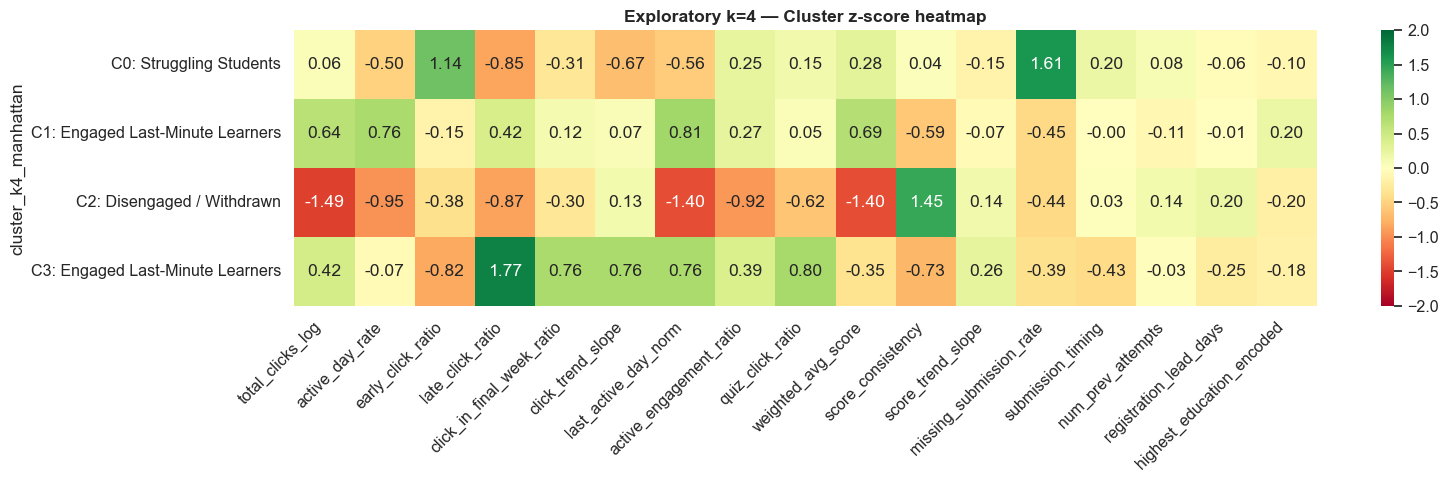

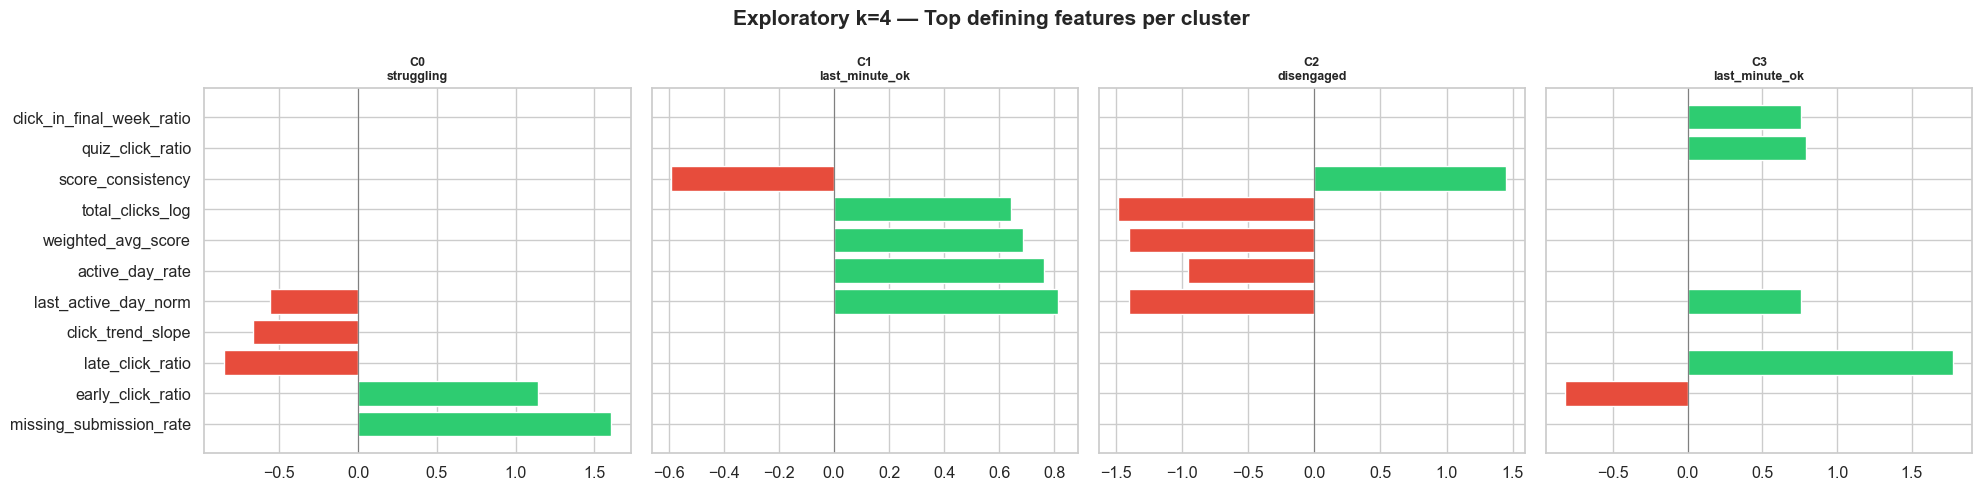

In [34]:
fig, ax = plt.subplots(figsize=(16, 5))
row_labels_k4 = [
    f"C{cid}: {ENSIA_CLUSTER_LABELS[classify_profile(z_k4.loc[cid])].split(' (')[0]}"
    for cid in z_k4.index
]
sns.heatmap(z_k4, annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-2, vmax=2, ax=ax)
ax.set_yticklabels(row_labels_k4, rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Exploratory k=4 — Cluster z-score heatmap', fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'k4_cluster_heatmap_zscores.png', dpi=150, bbox_inches='tight')
plt.show()

top_k4 = top_defining_features(z_k4, n_top=5)
fig, axes = plt.subplots(1, K_EXPLORE, figsize=(5 * K_EXPLORE, 5), sharey=True)
for ax, cid in zip(axes, sorted(z_k4.index)):
    sub = top_k4[top_k4['cluster'] == cid].sort_values('rank')
    colors = ['#2ecc71' if z > 0 else '#e74c3c' for z in sub['z_score']]
    ax.barh(sub['feature'], sub['z_score'], color=colors)
    pk = classify_profile(z_k4.loc[cid])
    ax.set_title(f'C{cid}\n{pk}', fontweight='bold', fontsize=9)
    ax.axvline(0, color='gray', lw=0.8)
fig.suptitle('Exploratory k=4 — Top defining features per cluster', fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'k4_top_defining_features.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** The k=4 heatmap should show **four distinct rows**. In this run, **C2** is clearly separated (all engagement features negative). **C0** vs **C1/C3** differ mainly on `missing_submission_rate` and activity level. **C1 vs C3** both look engaged but **C3** spikes on `late_click_ratio` (+1.78) and `click_in_final_week_ratio` (+0.76) — the bar charts make that split visible cluster-by-cluster. Saved to `k4_cluster_heatmap_zscores.png` and `k4_top_defining_features.png`.


### 11.6 Decision — Keep k = 3 or adopt k = 4?

| Criterion | **k = 3 (official)** — this run | **k = 4 (exploratory)** — this run |
|-----------|----------------------------------|-------------------------------------|
| Silhouette (Manhattan) | **0.261** | **0.191** (−0.070) |
| Davies–Bouldin | **1.72** | **2.05** (worse) |
| Brief: Consistent learner | Absorbed inside k=3 C0 (~55%) | **Not found** (0 `high_performer` clusters) |
| Brief: Last-minute | k=3 C0 (one big cluster) | **Two** clusters (C1 44% + C3 11%), both `last_minute_ok` |
| k=3 C0 split test | Internal silhouette **0.342** (mixed) | **79.7%** → k=4 C1, **20.2%** → k=4 C3 |
| k=3 C1 (struggling) | 22% of cohort | **97.1%** maps to k=4 C0 struggling |

**Decision:** Keep **k = 3** as the production model (`models/kmeans.pkl`, `cluster_manhattan`). Section 11 shows Cluster 0 **is** internally mixed and k=4 **does** subdivide it into moderate vs extreme last-minute groups, but k=4 **hurts global separation**, does **not** recover a Consistent/High Performer cluster, and mostly **relabels** k=3 struggling students into k=4 Cluster 0. The exploratory CSV and figures are kept for the report; the dashboard and deliverables stay on **k = 3**.


In [35]:
n_profiles_k4 = interp_k4['profile'].value_counts()
n_high = int(n_profiles_k4.get('high_performer', 0))
n_lm = int(n_profiles_k4.get('last_minute_ok', 0))
print('=== k=4 EXPLORATORY SUMMARY ===')
print(f"Distinct profile keys at k=4: {list(n_profiles_k4.index)}")
print(f"  high_performer clusters: {n_high}  |  last_minute_ok clusters: {n_lm}")
print(f"  struggling: {n_profiles_k4.get('struggling', 0)}  |  disengaged: {n_profiles_k4.get('disengaged', 0)}")
print(f"\nSaved: {RESULTS_DIR / 'cluster_interpretation_k4_exploratory.csv'}")
print(f"Figures: k4_cluster_heatmap_zscores.png, k4_top_defining_features.png")
print('\nOfficial production model unchanged: k=3 → models/kmeans.pkl (Manhattan)')


=== k=4 EXPLORATORY SUMMARY ===
Distinct profile keys at k=4: ['last_minute_ok', 'struggling', 'disengaged']
  high_performer clusters: 0  |  last_minute_ok clusters: 2
  struggling: 1  |  disengaged: 1

Saved: D:\Student-Learning-Behavior-Clustering-Profiling\reports\results\cluster_interpretation_k4_exploratory.csv
Figures: k4_cluster_heatmap_zscores.png, k4_top_defining_features.png

Official production model unchanged: k=3 → models/kmeans.pkl (Manhattan)


**Interpretation of the summary printout:** The console confirms **zero** `high_performer` clusters at k=4. We get **two** last-minute clusters, **one** struggling, and **one** disengaged — the same three archetypes as k=3, sliced differently. Artifacts: `reports/results/cluster_interpretation_k4_exploratory.csv` and `reports/figures/clustering/k4_*.png` (report appendix only). **`models/kmeans.pkl` remains k=3 Manhattan.**


---
## 12 · Summary & Conclusions

### Final Results Table

In [36]:
print('=== FINAL CLUSTER SUMMARY ===')
print(f'Dataset: {len(master_out):,} students | {len(FEATURE_COLS)} features | k={best_k}')
print(f'Primary model: Manhattan K-Means (Lloyd + scipy cdist)')
print(f'Silhouette (Manhattan): {m_manh["silhouette"]:.4f}')
print(f'Davies–Bouldin        : {m_manh["davies_bouldin"]:.4f}')
print(f'Stability (mean ARI)  : {mean_ari:.4f} ± {std_ari:.4f}')
print(f'Chi-squared Cramér\'s V: {cramers_v:.4f}')
print()

display_cols = ['cluster', 'label', 'risk', 'n_students', 'pct_students',
                'pct_pass', 'pct_fail_wd', 'intervention']
display(interp_df[display_cols])

print('\n=== SAVED FILES ===')
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  {f.relative_to(REPORT_DIR)}')

=== FINAL CLUSTER SUMMARY ===
Dataset: 32,593 students | 17 features | k=3
Primary model: Manhattan K-Means (Lloyd + scipy cdist)
Silhouette (Manhattan): 0.2612
Davies–Bouldin        : 1.7200
Stability (mean ARI)  : 0.9998 ± 0.0002
Chi-squared Cramér's V: 0.6256



,cluster,label,risk,n_students,pct_students,pct_pass,pct_fail_wd,intervention
0,0,Engaged Last-Minute Learners (Mostly On-Track),Low-moderate,17830,54.7,68.5,14.7,"Time-management nudges, earlier draft deadline..."
1,1,Struggling Students (High Missing Work),High,7185,22.0,1.7,98.2,Academic advising + missing-work recovery befo...
2,2,Disengaged / Withdrawn (Minimal VLE Use),Very high,7578,23.3,0.4,99.5,"Early-week zero-activity alert (weeks 1–3), we..."



=== SAVED FILES ===
  figures\clustering\centroid_heatmap_sizes.png
  figures\clustering\cluster_heatmap_zscores.png
  figures\clustering\cluster_outcome_stacked.png
  figures\clustering\cluster_stability_ari.png
  figures\clustering\distance_distributions.png
  figures\clustering\k4_cluster_heatmap_zscores.png
  figures\clustering\k4_top_defining_features.png
  figures\clustering\k_selection_combined.png
  figures\clustering\metric_comparison_sweep.png
  figures\clustering\pca_clusters.png
  figures\clustering\preprocessing_outlier_clip.png
  figures\clustering\radar_profiles.png
  figures\clustering\silhouette_per_sample.png
  figures\clustering\top_defining_features_per_cluster.png
  figures\clustering\umap_clusters.png


### Key Findings

1. **Behavioral structure exists** — K-Means on 17 VLE+assessment features discovers stable, educationally meaningful clusters without any grade/outcome labels during training.

2. **Cluster profiles are distinct** — The updated classifier distinguishes four profiles using `click_trend_slope`, `late_click_ratio`, `click_in_final_week_ratio`, and `weighted_avg_score` jointly. The original code collapsed consistent and last-minute learners by relying on clicks+score alone.

3. **±4σ clipping is safe** — Only a tiny fraction of matrix entries were changed; the operation prevents outlier students from distorting centroids without removing any data.

4. **Manhattan is the right metric** — Higher coefficient of variation in pairwise distances compared to Euclidean; theoretically preferred for p=17 dimensions; robust to the outliers identified in preprocessing.

5. **Strong post-hoc validation** — The chi-squared test (p ≪ 0.001, Cramér's V ≥ 0.30) confirms clusters align strongly with actual outcomes. At-risk clusters (struggling + disengaged) flag students with high Fail+Withdrawn rates using behavioral features only.

### Limitations

- **Soft boundaries:** Silhouette 0.20–0.35 is expected for behavioral data — students do not fall into hard clusters. Some overlap is inherent, not a failure.
- **All modules pooled:** Module-specific effects (duration, difficulty) may blur clusters. Future work: stratify by `code_module`.
- **Behavior ≠ ability:** High VLE activity does not guarantee Pass; low activity does not guarantee Fail.
- **2D projections:** PCA and UMAP are views, not the full 17D structure.

### Future Work

- Stratify clustering by `code_module` / presentation year
- Sequence models (LSTM) on weekly VLE click time series
- Apply pipeline to ENSIA LMS data
- Hierarchical clustering to explore sub-clusters within the last-minute group

In [37]:
# Save final master with cluster labels
master_out.to_csv(PROC_DIR / 'master_features_with_clusters.csv', index=False)
print(f'Saved: data/processed/master_features_with_clusters.csv  ({len(master_out):,} rows)')
print('\nAll outputs:')
print(f'  Models : {MOD_DIR}')
print(f'  Figures: {FIG_DIR}')
print(f'  Tables : {RESULTS_DIR}')

Saved: data/processed/master_features_with_clusters.csv  (32,593 rows)

All outputs:
  Models : D:\Student-Learning-Behavior-Clustering-Profiling\models
  Figures: D:\Student-Learning-Behavior-Clustering-Profiling\reports\figures\clustering
  Tables : D:\Student-Learning-Behavior-Clustering-Profiling\reports\results
